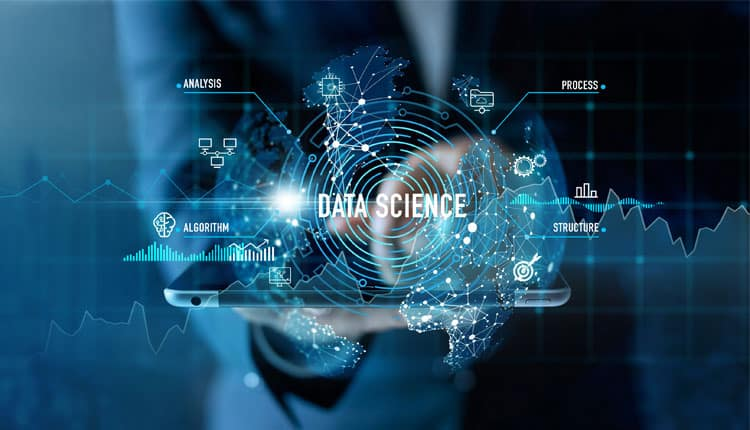

## TRABAJO PRACTICO N°1
Pereyra Victoria Luz

# **1. MODULOS**

In [ ]:
# Importación Modulos
import numpy as np
import pandas as pd
import pandas.testing as tm
from pandas.core.frame import DataFrame
import datetime as dt

# Gráficos
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale
import warnings
warnings.filterwarnings('ignore')

# PCA
from sklearn.decomposition import PCA
from pandas.core.frame import DataFrame
from sklearn import preprocessing

# Imputacion de datos
import sklearn
from sklearn.impute import SimpleImputer
import sklearn as sk
from sklearn import model_selection
from sklearn import tree
from sklearn import metrics

#Cluesting
from scipy.spatial import distance
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import confusion_matrix

In [ ]:
# Vinculo Google Colab con Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **2. DATAFRAME**

In [ ]:
# Importar Base de datos - Empresas
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Base de datos/empresas.csv")

In [ ]:
#Informacion de los primeros registros
df.head()

,ID,Cantidad_Empleados,Ventas_Anuales_USD,Sueldos_Pagados_USD,Inversión_Anual_USD,Condición_OK
0,1,112,6649054,4419184,1316702,True
1,2,445,9948595,9354345,268969,True
2,3,870,30928216,27538110,172409,True
3,4,280,23329598,17800440,1646283,True
4,5,116,7275755,3876372,303618,True


In [ ]:
df = df.drop('Condición_OK', axis=1)

In [ ]:
#Informacion de la base de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   90 non-null     int64
 1   Cantidad_Empleados   90 non-null     int64
 2   Ventas_Anuales_USD   90 non-null     int64
 3   Sueldos_Pagados_USD  90 non-null     int64
 4   Inversión_Anual_USD  90 non-null     int64
dtypes: int64(5)
memory usage: 3.6 KB


In [ ]:
df.rename(columns={'Cantidad_Empleados': 'cantidad_empleados',
                   'Ventas_Anuales_USD': 'ventas_anuales_USD',
                   'Sueldos_Pagados_USD': 'sueldos_pagados_USD',
                   'Inversión_Anual_USD': 'inversión_anual_USD'}, inplace=True)
df

,ID,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD
0,1,112,6649054,4419184,1316702
1,2,445,9948595,9354345,268969
2,3,870,30928216,27538110,172409
3,4,280,23329598,17800440,1646283
4,5,116,7275755,3876372,303618
...,...,...,...,...,...
85,86,90,7250697,5890770,641460
86,87,941,45791281,42764686,790976
87,88,571,48334117,43447390,831239
88,89,881,70843031,64876840,1191840


# **3. ANALISIS DE BASE DE DATOS**

In [ ]:
import sys
!{sys.executable} -m pip install -U ydata-profiling[notebook]
!jupyter nbextension enable --py widgetsnbextension

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.3/399.3 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing in

In [ ]:
from ydata_profiling import ProfileReport

In [ ]:
# @title
profile = ProfileReport(df, title="Reporte de Perfilado", explorative=True)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 41.87it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# **4. NUEVAS COLUMNAS CALCULADAS**

In [ ]:
# Ventas netas
df['ventas_netas'] = df['ventas_anuales_USD'] - df['sueldos_pagados_USD']
df.head(10)

,ID,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas
0,1,112,6649054,4419184,1316702,2229870
1,2,445,9948595,9354345,268969,594250
2,3,870,30928216,27538110,172409,3390106
3,4,280,23329598,17800440,1646283,5529158
4,5,116,7275755,3876372,303618,3399383
5,6,81,7101729,5912595,819598,1189134
6,7,710,48758154,43137470,1148591,5620684
7,8,30,3375327,890760,822838,2484567
8,9,624,44576473,41032992,1220672,3543481
9,10,131,6031955,3520363,1729923,2511592


In [ ]:
mean = round(df['ventas_netas'].mean(),2)
mean

np.float64(3533904.04)

In [ ]:
#Columna condicional Tipo de Ingresos
df['ingresos_categoria'] = np.where(df['ventas_netas'] > mean, 'Altos', 'Bajos')
df.head()

,ID,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,ingresos_categoria
0,1,112,6649054,4419184,1316702,2229870,Bajos
1,2,445,9948595,9354345,268969,594250,Bajos
2,3,870,30928216,27538110,172409,3390106,Bajos
3,4,280,23329598,17800440,1646283,5529158,Altos
4,5,116,7275755,3876372,303618,3399383,Bajos


In [ ]:
df.ingresos_categoria.value_counts().sort_index()

,count
ingresos_categoria,
Altos,42
Bajos,48


In [ ]:
df['cantidad_empleados'].describe()

,cantidad_empleados
count,90.000000
mean,481.322222
std,288.692318
min,23.000000
25%,251.500000
50%,468.500000
75%,709.750000
max,985.000000


In [ ]:
mean_empleados = round(df['cantidad_empleados'].mean(),2)
mean_empleados

np.float64(481.32)

In [ ]:
#Columna condicional Tipo de Empresa
condiciones = [
    (df['cantidad_empleados'] < 10),
    (df['cantidad_empleados'] >= 10) & (df['cantidad_empleados'] < 50),
    (df['cantidad_empleados'] >= 50) & (df['cantidad_empleados'] < 250),
    (df['cantidad_empleados'] >= 250)]

categorias = [
    'Microempresa',
    'Pequeña Empresa',
    'Empresa Mediana',
    'Empresa Grande']

df['empresa_categoria'] = np.select(condiciones,categorias, default = 'Sin Categoria')

df.head()

,ID,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,ingresos_categoria,empresa_categoria
0,1,112,6649054,4419184,1316702,2229870,Bajos,Empresa Mediana
1,2,445,9948595,9354345,268969,594250,Bajos,Empresa Grande
2,3,870,30928216,27538110,172409,3390106,Bajos,Empresa Grande
3,4,280,23329598,17800440,1646283,5529158,Altos,Empresa Grande
4,5,116,7275755,3876372,303618,3399383,Bajos,Empresa Mediana


In [ ]:
#Porcentaje invertido segun los ingresos netos de costos
df['porcentaje_inversion'] =  round((df['inversión_anual_USD'] / df['ventas_netas']) * 100,2)
df.head(10)

,ID,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,ingresos_categoria,empresa_categoria,porcentaje_inversion
0,1,112,6649054,4419184,1316702,2229870,Bajos,Empresa Mediana,59.05
1,2,445,9948595,9354345,268969,594250,Bajos,Empresa Grande,45.26
2,3,870,30928216,27538110,172409,3390106,Bajos,Empresa Grande,5.09
3,4,280,23329598,17800440,1646283,5529158,Altos,Empresa Grande,29.77
4,5,116,7275755,3876372,303618,3399383,Bajos,Empresa Mediana,8.93
5,6,81,7101729,5912595,819598,1189134,Bajos,Empresa Mediana,68.92
6,7,710,48758154,43137470,1148591,5620684,Altos,Empresa Grande,20.44
7,8,30,3375327,890760,822838,2484567,Bajos,Pequeña Empresa,33.12
8,9,624,44576473,41032992,1220672,3543481,Altos,Empresa Grande,34.45
9,10,131,6031955,3520363,1729923,2511592,Bajos,Empresa Mediana,68.88


In [ ]:
#Columna condicional de inversiones segun el porcentaje reinvertido en la organizacion
mean_inversion = round(df['porcentaje_inversion'].mean(),2)

condiciones = [
    (df['porcentaje_inversion'] < 20),
    (df['porcentaje_inversion'] >= 20) & (df['porcentaje_inversion'] < mean_inversion),
    (df['porcentaje_inversion'] >= mean_inversion)]

categorias = [
    'Bajo',
    'Medio',
    'Alto']

df['inversion_categoria'] = np.select(condiciones,categorias, default = 'Sin Categoria')

df.head()

,ID,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,ingresos_categoria,empresa_categoria,porcentaje_inversion,inversion_categoria
0,1,112,6649054,4419184,1316702,2229870,Bajos,Empresa Mediana,59.05,Alto
1,2,445,9948595,9354345,268969,594250,Bajos,Empresa Grande,45.26,Alto
2,3,870,30928216,27538110,172409,3390106,Bajos,Empresa Grande,5.09,Bajo
3,4,280,23329598,17800440,1646283,5529158,Altos,Empresa Grande,29.77,Medio
4,5,116,7275755,3876372,303618,3399383,Bajos,Empresa Mediana,8.93,Bajo


In [ ]:
mean_inversion

np.float64(31.34)

In [ ]:
#Categoria de Inversion
# Frecuencia absoluta
freq_abs = df['inversion_categoria'].value_counts().rename("Quantity")

# Frecuencia relativa
freq_rel = df['inversion_categoria'].value_counts(normalize=True).rename("Quantity (%)")

# pd.concat
tabla = pd.concat([freq_abs, freq_rel], axis=1)
tabla

,Quantity,Quantity (%)
inversion_categoria,,
Alto,37,0.411111
Bajo,28,0.311111
Medio,25,0.277778


In [ ]:
#Porcentaje de costos sobre las ventas totales
df['porcentaje_costos'] = round((df['sueldos_pagados_USD'] / df['ventas_anuales_USD']) * 100,2)
df.head(10)


,ID,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,ingresos_categoria,empresa_categoria,porcentaje_inversion,inversion_categoria,porcentaje_costos
0,1,112,6649054,4419184,1316702,2229870,Bajos,Empresa Mediana,59.05,Alto,66.46
1,2,445,9948595,9354345,268969,594250,Bajos,Empresa Grande,45.26,Alto,94.03
2,3,870,30928216,27538110,172409,3390106,Bajos,Empresa Grande,5.09,Bajo,89.04
3,4,280,23329598,17800440,1646283,5529158,Altos,Empresa Grande,29.77,Medio,76.30
4,5,116,7275755,3876372,303618,3399383,Bajos,Empresa Mediana,8.93,Bajo,53.28
5,6,81,7101729,5912595,819598,1189134,Bajos,Empresa Mediana,68.92,Alto,83.26
6,7,710,48758154,43137470,1148591,5620684,Altos,Empresa Grande,20.44,Medio,88.47
7,8,30,3375327,890760,822838,2484567,Bajos,Pequeña Empresa,33.12,Alto,26.39
8,9,624,44576473,41032992,1220672,3543481,Altos,Empresa Grande,34.45,Alto,92.05
9,10,131,6031955,3520363,1729923,2511592,Bajos,Empresa Mediana,68.88,Alto,58.36


In [ ]:
#Columna condicional de costos segun el porcentaje pagado en sueldos en la organizacion
mean_costos = round(df['porcentaje_costos'].mean(),2)

condiciones = [
    (df['porcentaje_costos'] < 20) & (df['porcentaje_costos'] > 50),
    (df['porcentaje_costos'] >= 50) & (df['porcentaje_costos'] < mean_costos),
    (df['porcentaje_costos'] >= mean_costos)]

categorias = [
    'Bajo',
    'Medio',
    'Alto']

df['costos_categoria'] = np.select(condiciones,categorias, default = 'Sin Categoria')

df.head()

,ID,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,ingresos_categoria,empresa_categoria,porcentaje_inversion,inversion_categoria,porcentaje_costos,costos_categoria
0,1,112,6649054,4419184,1316702,2229870,Bajos,Empresa Mediana,59.05,Alto,66.46,Medio
1,2,445,9948595,9354345,268969,594250,Bajos,Empresa Grande,45.26,Alto,94.03,Alto
2,3,870,30928216,27538110,172409,3390106,Bajos,Empresa Grande,5.09,Bajo,89.04,Alto
3,4,280,23329598,17800440,1646283,5529158,Altos,Empresa Grande,29.77,Medio,76.30,Medio
4,5,116,7275755,3876372,303618,3399383,Bajos,Empresa Mediana,8.93,Bajo,53.28,Medio


In [ ]:
mean_costos

np.float64(79.43)

In [ ]:
# Frecuencia absoluta
freq_abs = df['costos_categoria'].value_counts().rename("Quantity")

# Frecuencia relativa
freq_rel = df['costos_categoria'].value_counts(normalize=True).rename("Quantity (%)")

# pd.concat
tabla = pd.concat([freq_abs, freq_rel], axis=1)
tabla

,Quantity,Quantity (%)
costos_categoria,,
Alto,58,0.644444
Medio,25,0.277778
Sin Categoria,7,0.077778


# **5. ANALISIS DESCRIPTIVO VARIABLES UNIVARIADAS**


In [ ]:
df.groupby('ingresos_categoria')['ventas_anuales_USD'].sum()

,ventas_anuales_USD
ingresos_categoria,
Altos,1333770760
Bajos,1096262155


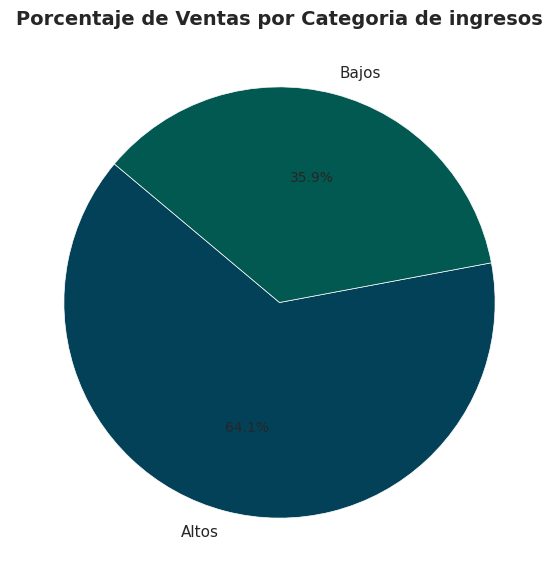

In [ ]:
# Crear el gráfico
ventas_por_categoria = df.groupby('ingresos_categoria')['ventas_netas'].sum()
colores = ["#034159","#025951"]

# Gráfico de pastel
plt.figure(figsize=(7,7))
plt.pie(
    ventas_por_categoria,
    labels=ventas_por_categoria.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colores,
    wedgeprops={"edgecolor":"white"}
)
plt.title("Porcentaje de Ventas por Categoria de ingresos", fontsize=14, weight="bold")
plt.show()

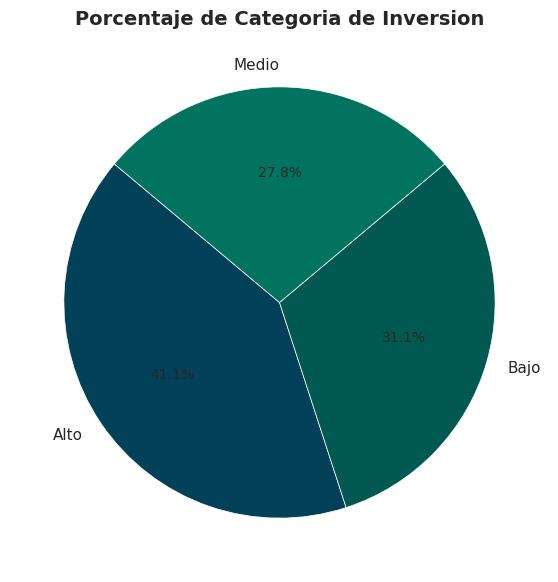

In [ ]:
#Graficar Categoria de Inversion
freq_rel = df['inversion_categoria'].value_counts(normalize=True).rename("Quantity (%)")
colores = ["#034159","#025951","#02735E"]
# Gráfico de pastel
plt.figure(figsize=(7,7))
plt.pie(
    freq_rel,
    labels=freq_rel.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colores,
    wedgeprops={"edgecolor":"white"}
)
plt.title("Porcentaje de Categoria de Inversion", fontsize=14, weight="bold")
plt.show()

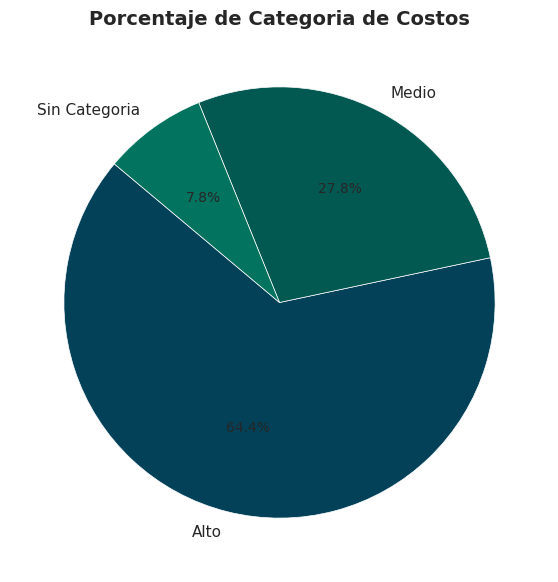

In [ ]:
#Graficar Categoria de Costos
freq_rel = df['costos_categoria'].value_counts(normalize=True).rename("Quantity (%)")
colores = ["#034159","#025951","#02735E"]
# Gráfico de pastel
plt.figure(figsize=(7,7))
plt.pie(
    freq_rel,
    labels=freq_rel.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colores,
    wedgeprops={"edgecolor":"white"}
)
plt.title("Porcentaje de Categoria de Costos", fontsize=14, weight="bold")
plt.show()

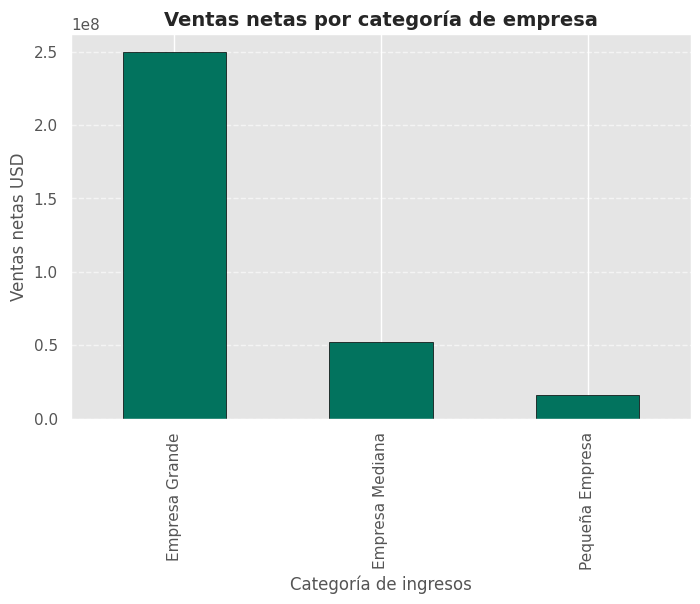

In [ ]:
#Volumen de Ventas segun el tamaño de la organizacion
ventas_por_empresa = df.groupby('empresa_categoria')['ventas_netas'].sum()
#Graficar
plt.figure(figsize=(8,5))
ventas_por_empresa.plot( kind="bar", color="#02735E", edgecolor="black")
plt.title("Ventas netas por categoría de empresa", fontsize=14, weight="bold")
plt.xlabel("Categoría de ingresos")
plt.ylabel("Ventas netas USD")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

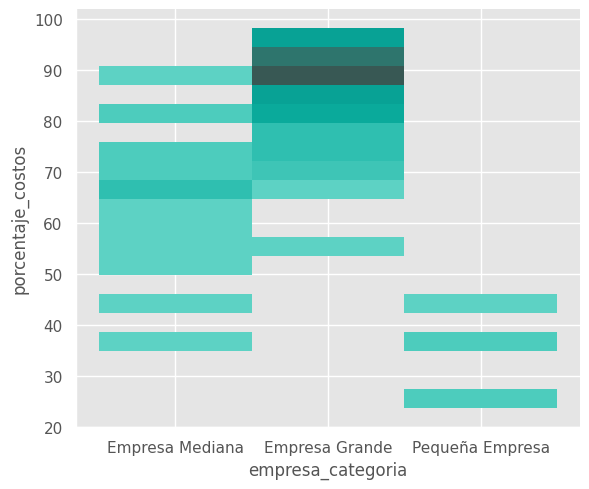

In [ ]:
sns.displot(df, x="empresa_categoria", y= "porcentaje_costos", color= "#025951",bins=20,aspect=1.2)
plt.show()

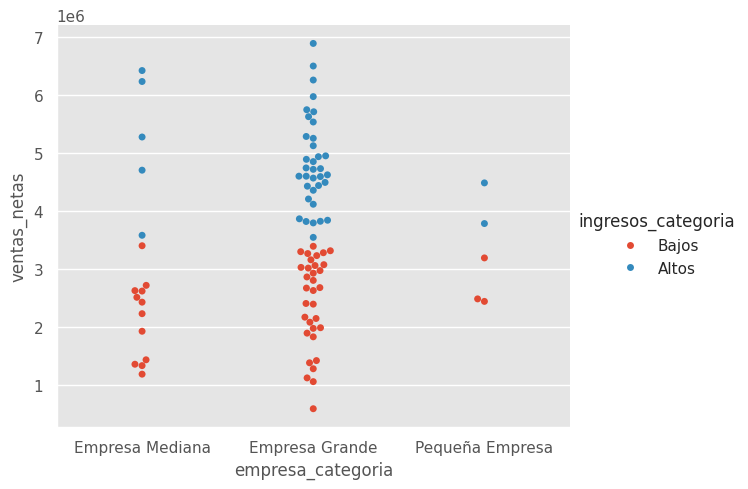

In [ ]:
# Gráfico de dispersion de ventas por tipo de empresa y tipo de ingresos
sns.catplot(data=df, x="empresa_categoria", y="ventas_netas", hue="ingresos_categoria",
    kind="swarm",aspect=1.2,)
plt.show()

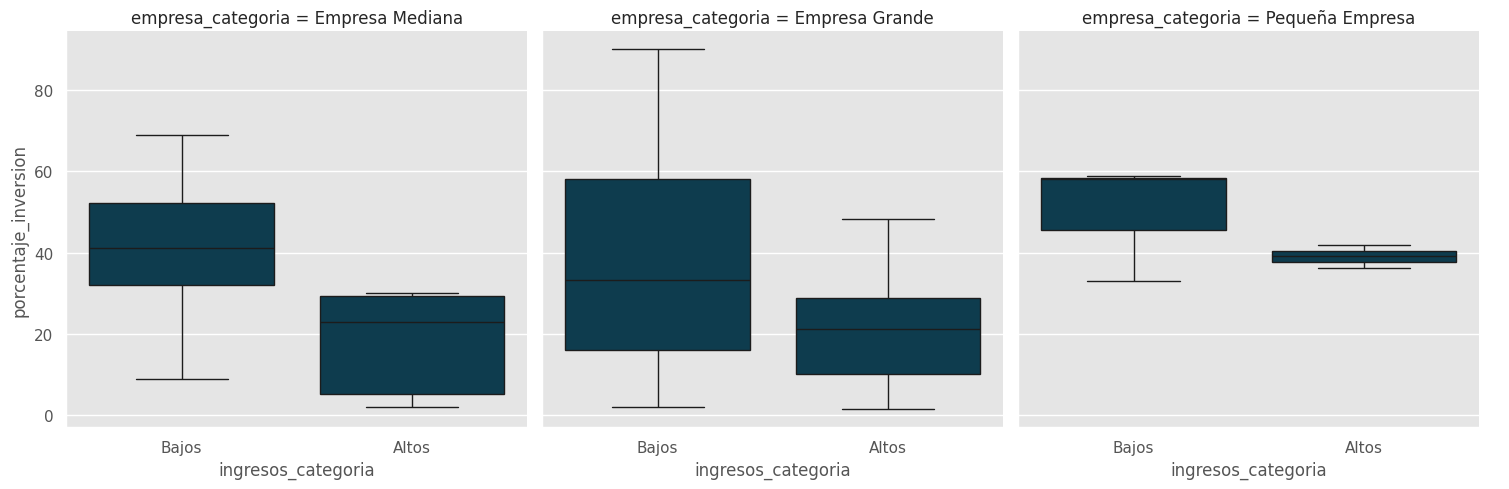

In [ ]:
sns.catplot(data=df, x="ingresos_categoria", y="porcentaje_inversion",col= "empresa_categoria",color="#034159", kind="box")

In [ ]:
!pip install autoviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.5/175.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 58.1 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.0.5
    Uninstalling xgboost-3.0.5:
      Successfully uninstalled xgboost-3.0.5


Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)
Shape of your Data Set loaded: (90, 12)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
  Printing up to 30 columns (max) in each category:
    Numeric Columns : ['porcentaje_inversion', 'porcentaje_costos']
    Integer-Categorical Columns: ['cantidad_empleados']
    String-Categorical Columns: ['empresa_categoria', 'inversion_categoria', 'costos_categoria']
    Factor-Categorical Columns: []
    String-Boolean Columns: ['ingresos_categori

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
ID,int64,0.000000,100,1.000000,90.000000,Possible ID column: drop before modeling step.
cantidad_empleados,int64,0.000000,93,23.000000,985.000000,No issue
ventas_anuales_USD,int64,0.000000,100,3375327.000000,82092235.000000,Possible ID column: drop before modeling step.
sueldos_pagados_USD,int64,0.000000,100,890760.000000,77656415.000000,Possible ID column: drop before modeling step.
inversión_anual_USD,int64,0.000000,100,71959.000000,1980267.000000,Possible ID column: drop before modeling step.
ventas_netas,int64,0.000000,100,594250.000000,6881436.000000,Possible ID column: drop before modeling step.
ingresos_categoria,object,0.000000,2,,,No issue
empresa_categoria,object,0.000000,3,,,No issue
porcentaje_inversion,float64,0.000000,NA,1.570000,89.920000,Column has 4 outliers greater than upper bound (80.29) or lower than lower bound(-22.69). Cap them or remove them.
inversion_categoria,object,0.000000,3,,,No issue


Number of All Scatter Plots = 3
All Plots are saved in av_out/AutoViz
Time to run AutoViz = 9 seconds 
Se generaron 6 gráficos


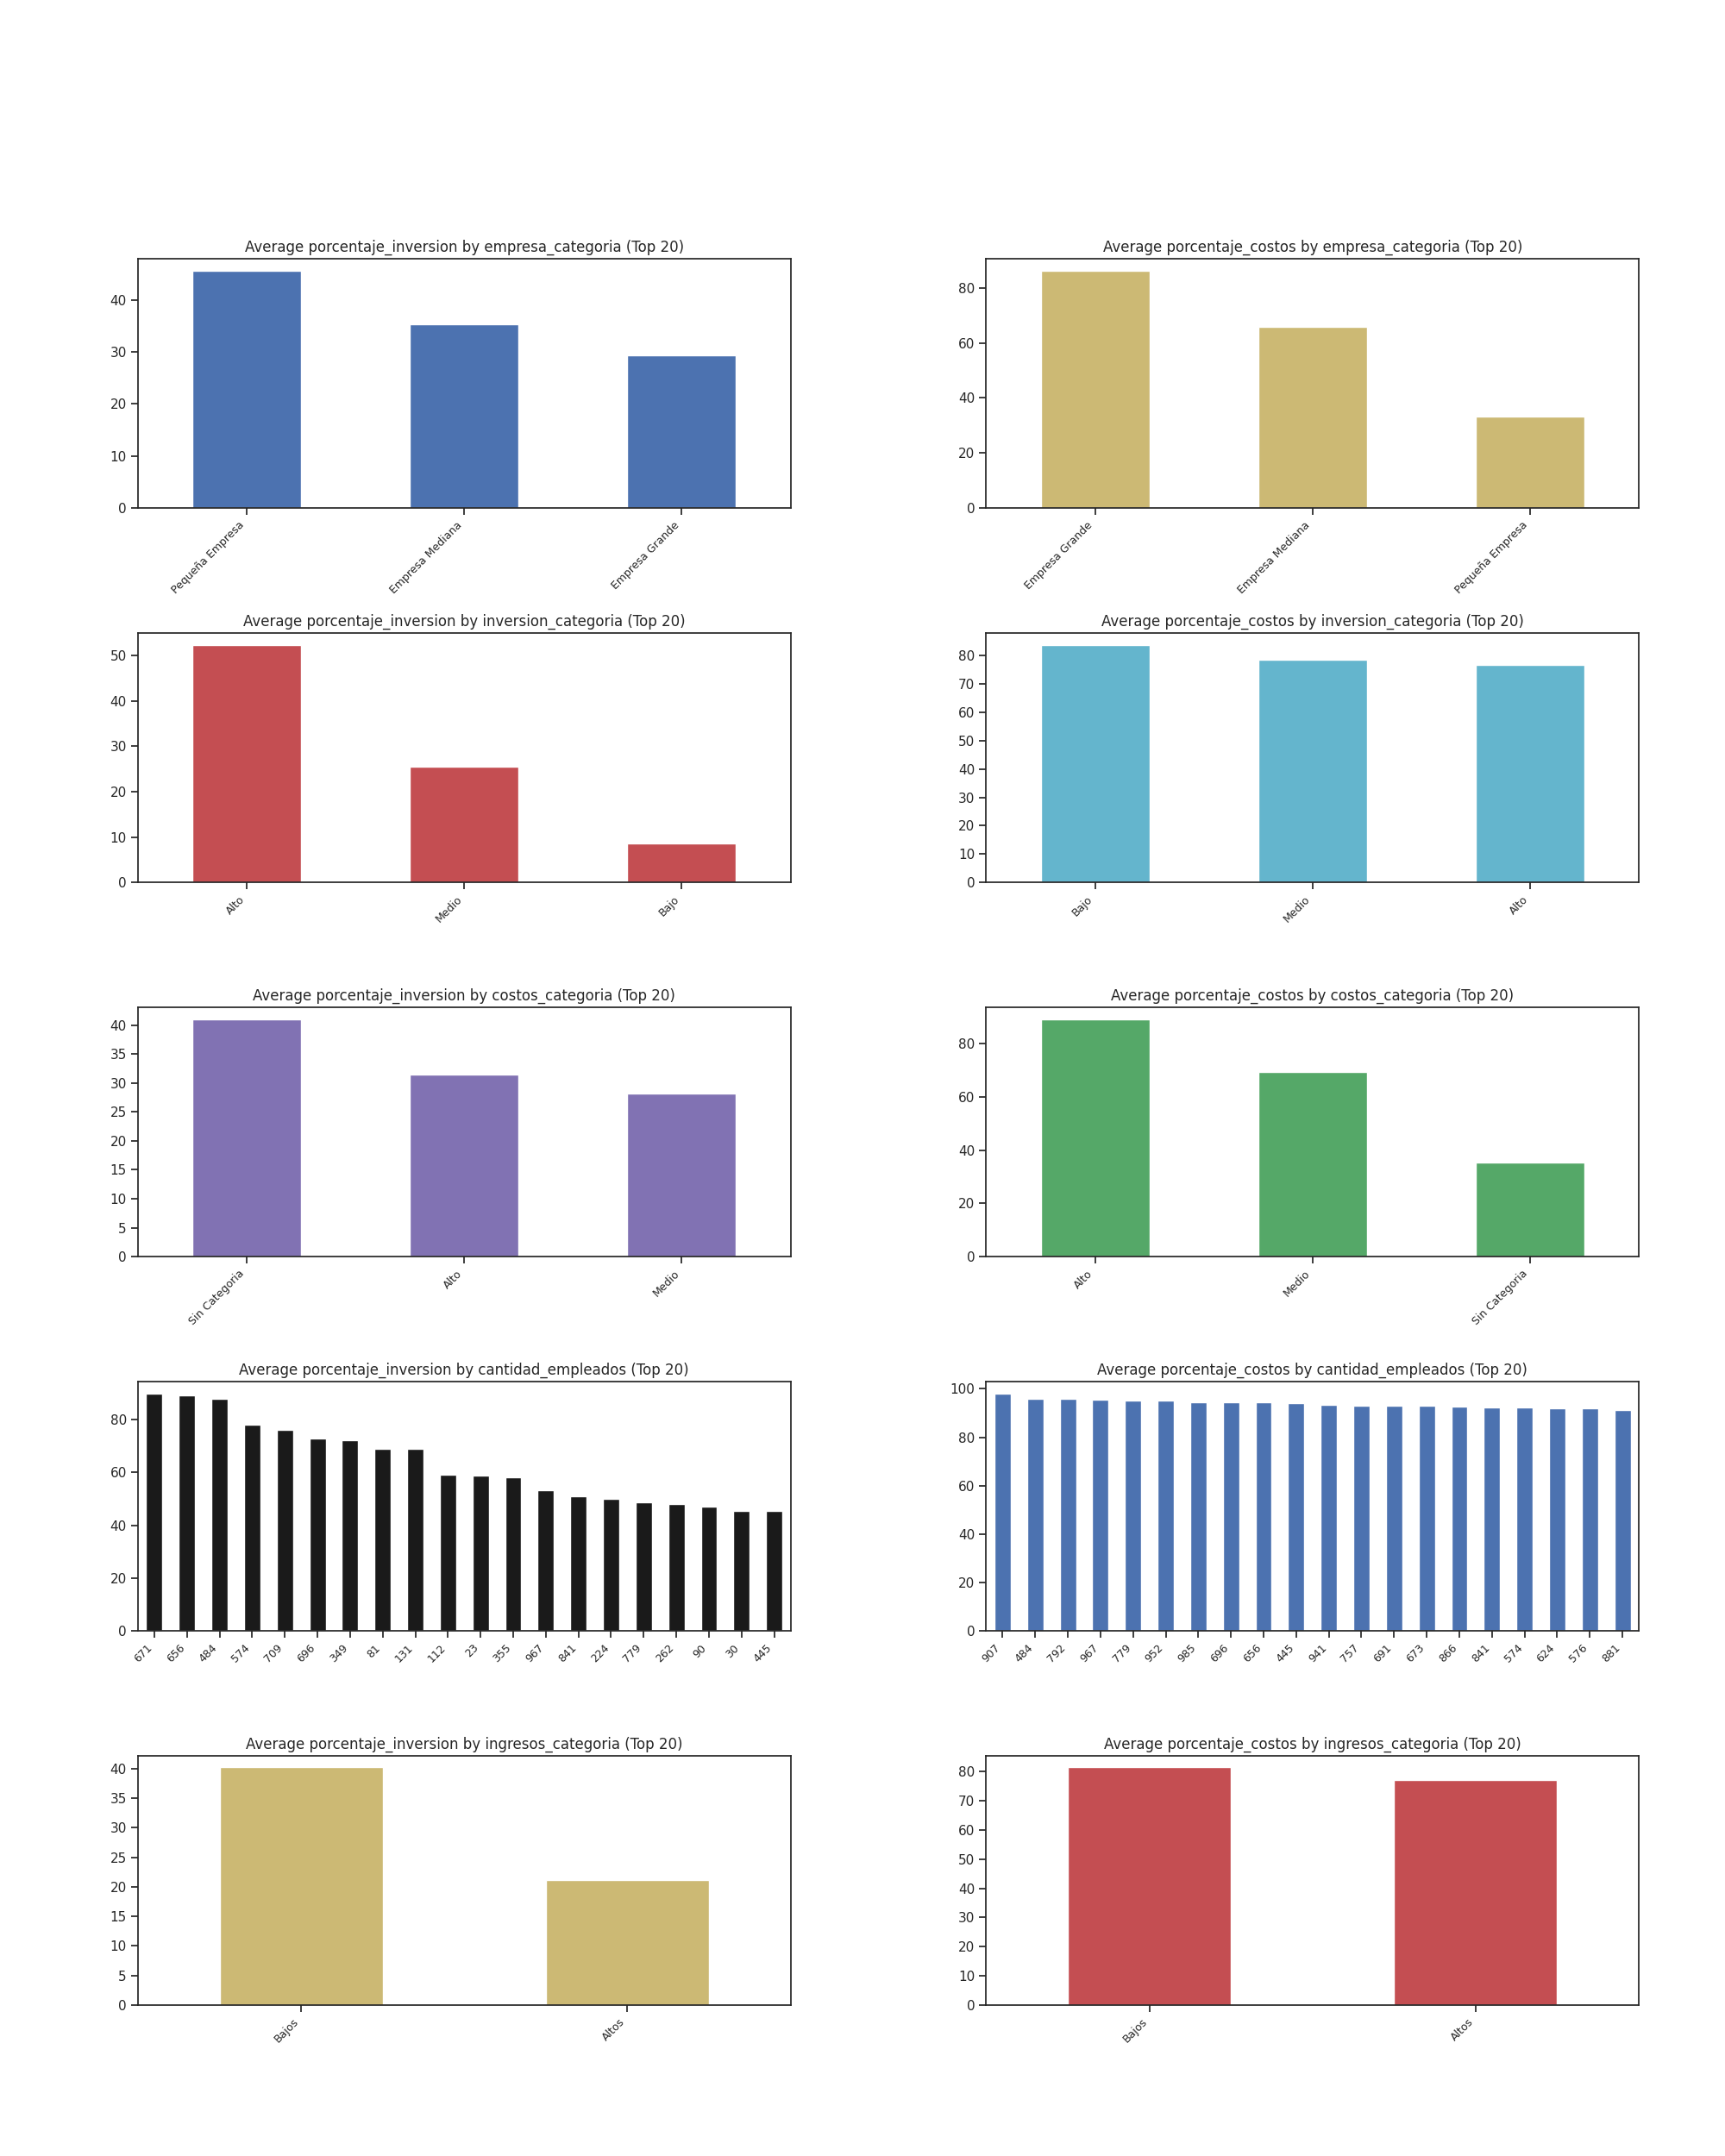

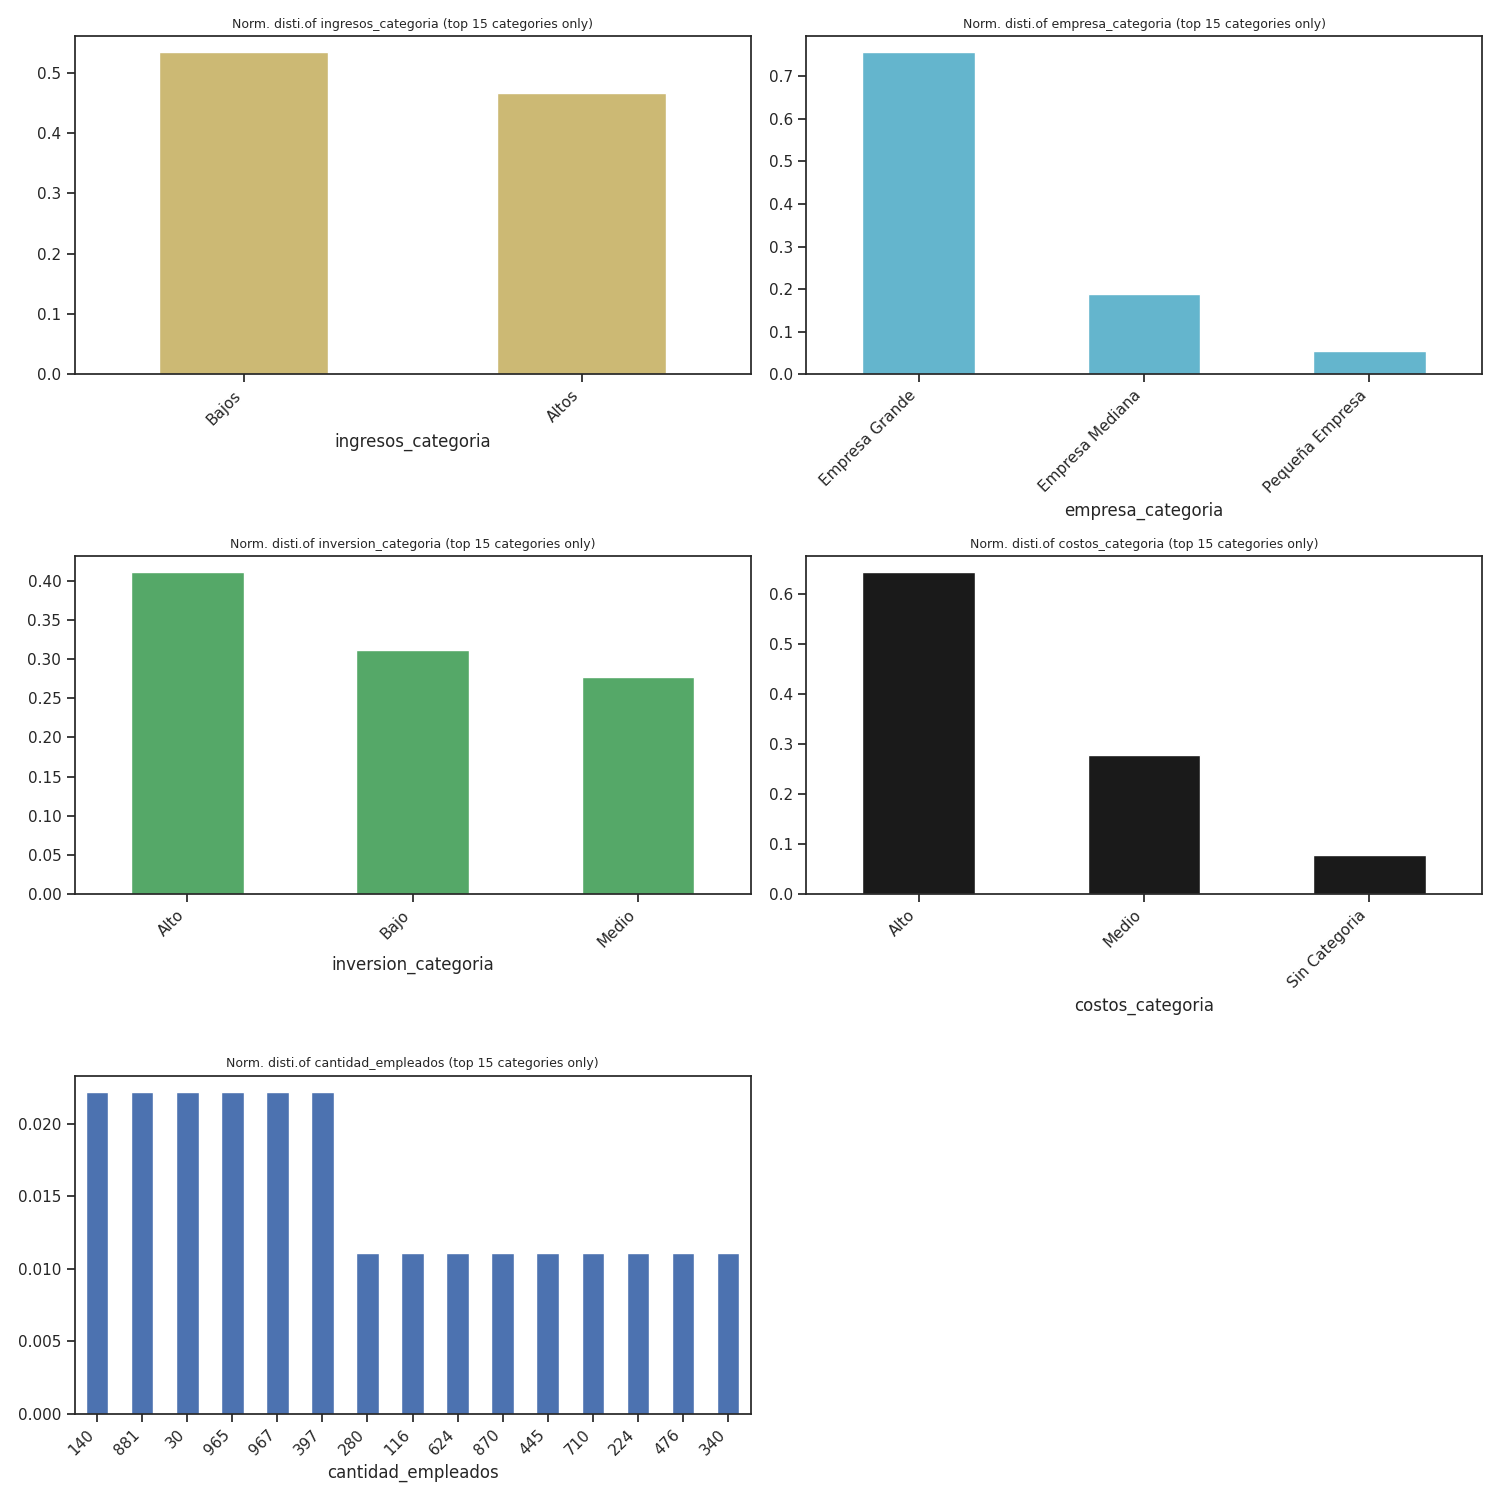

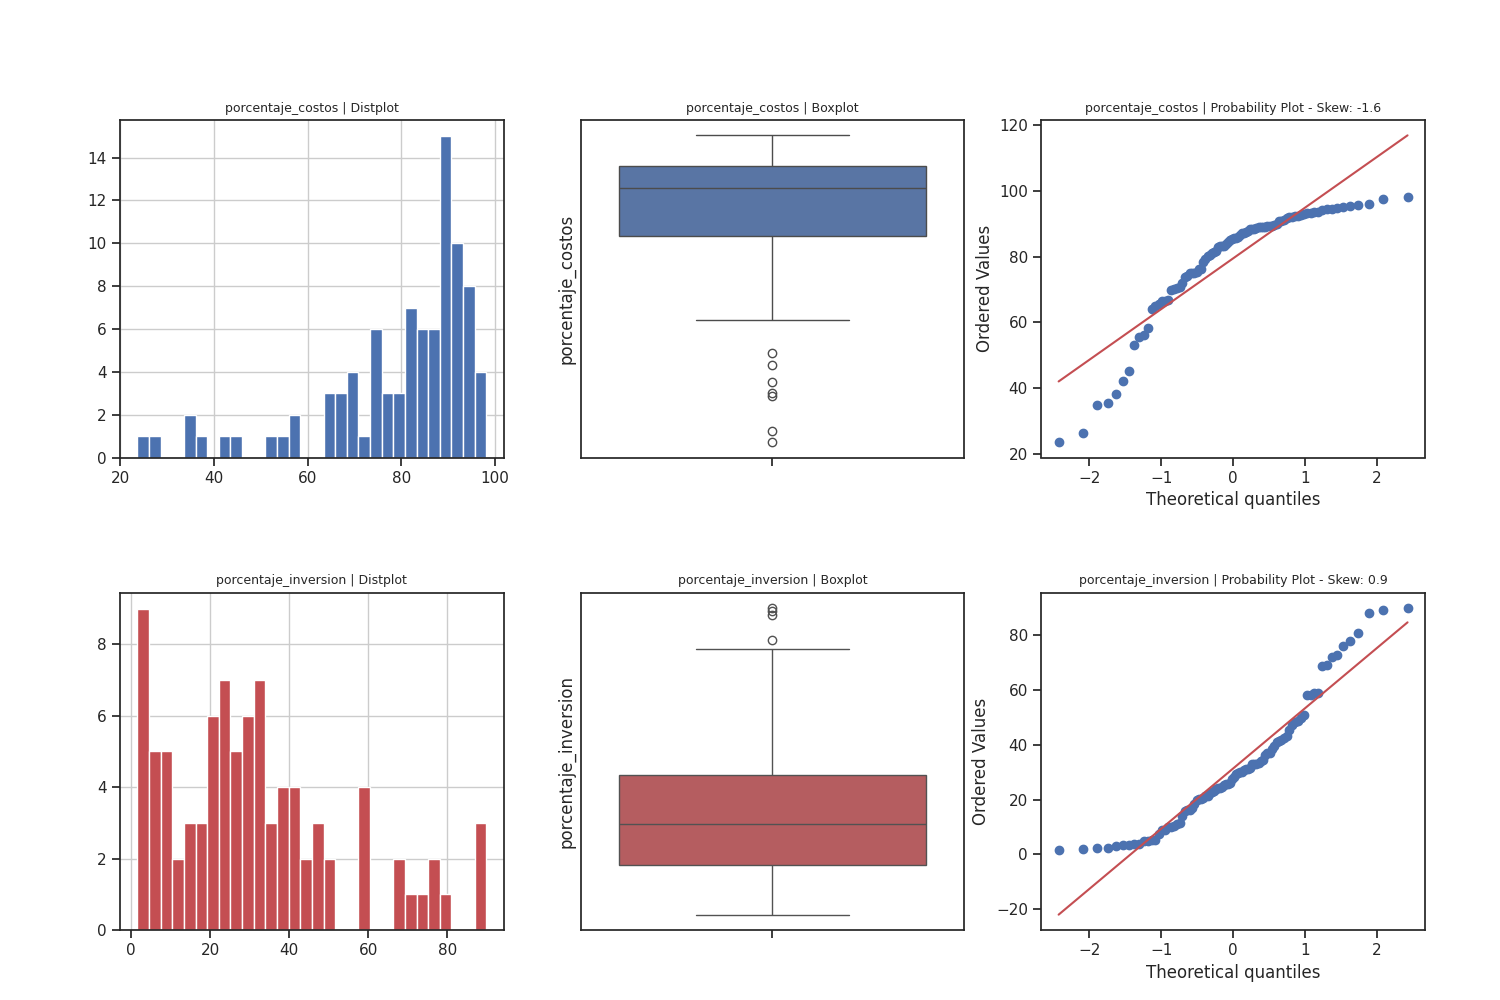

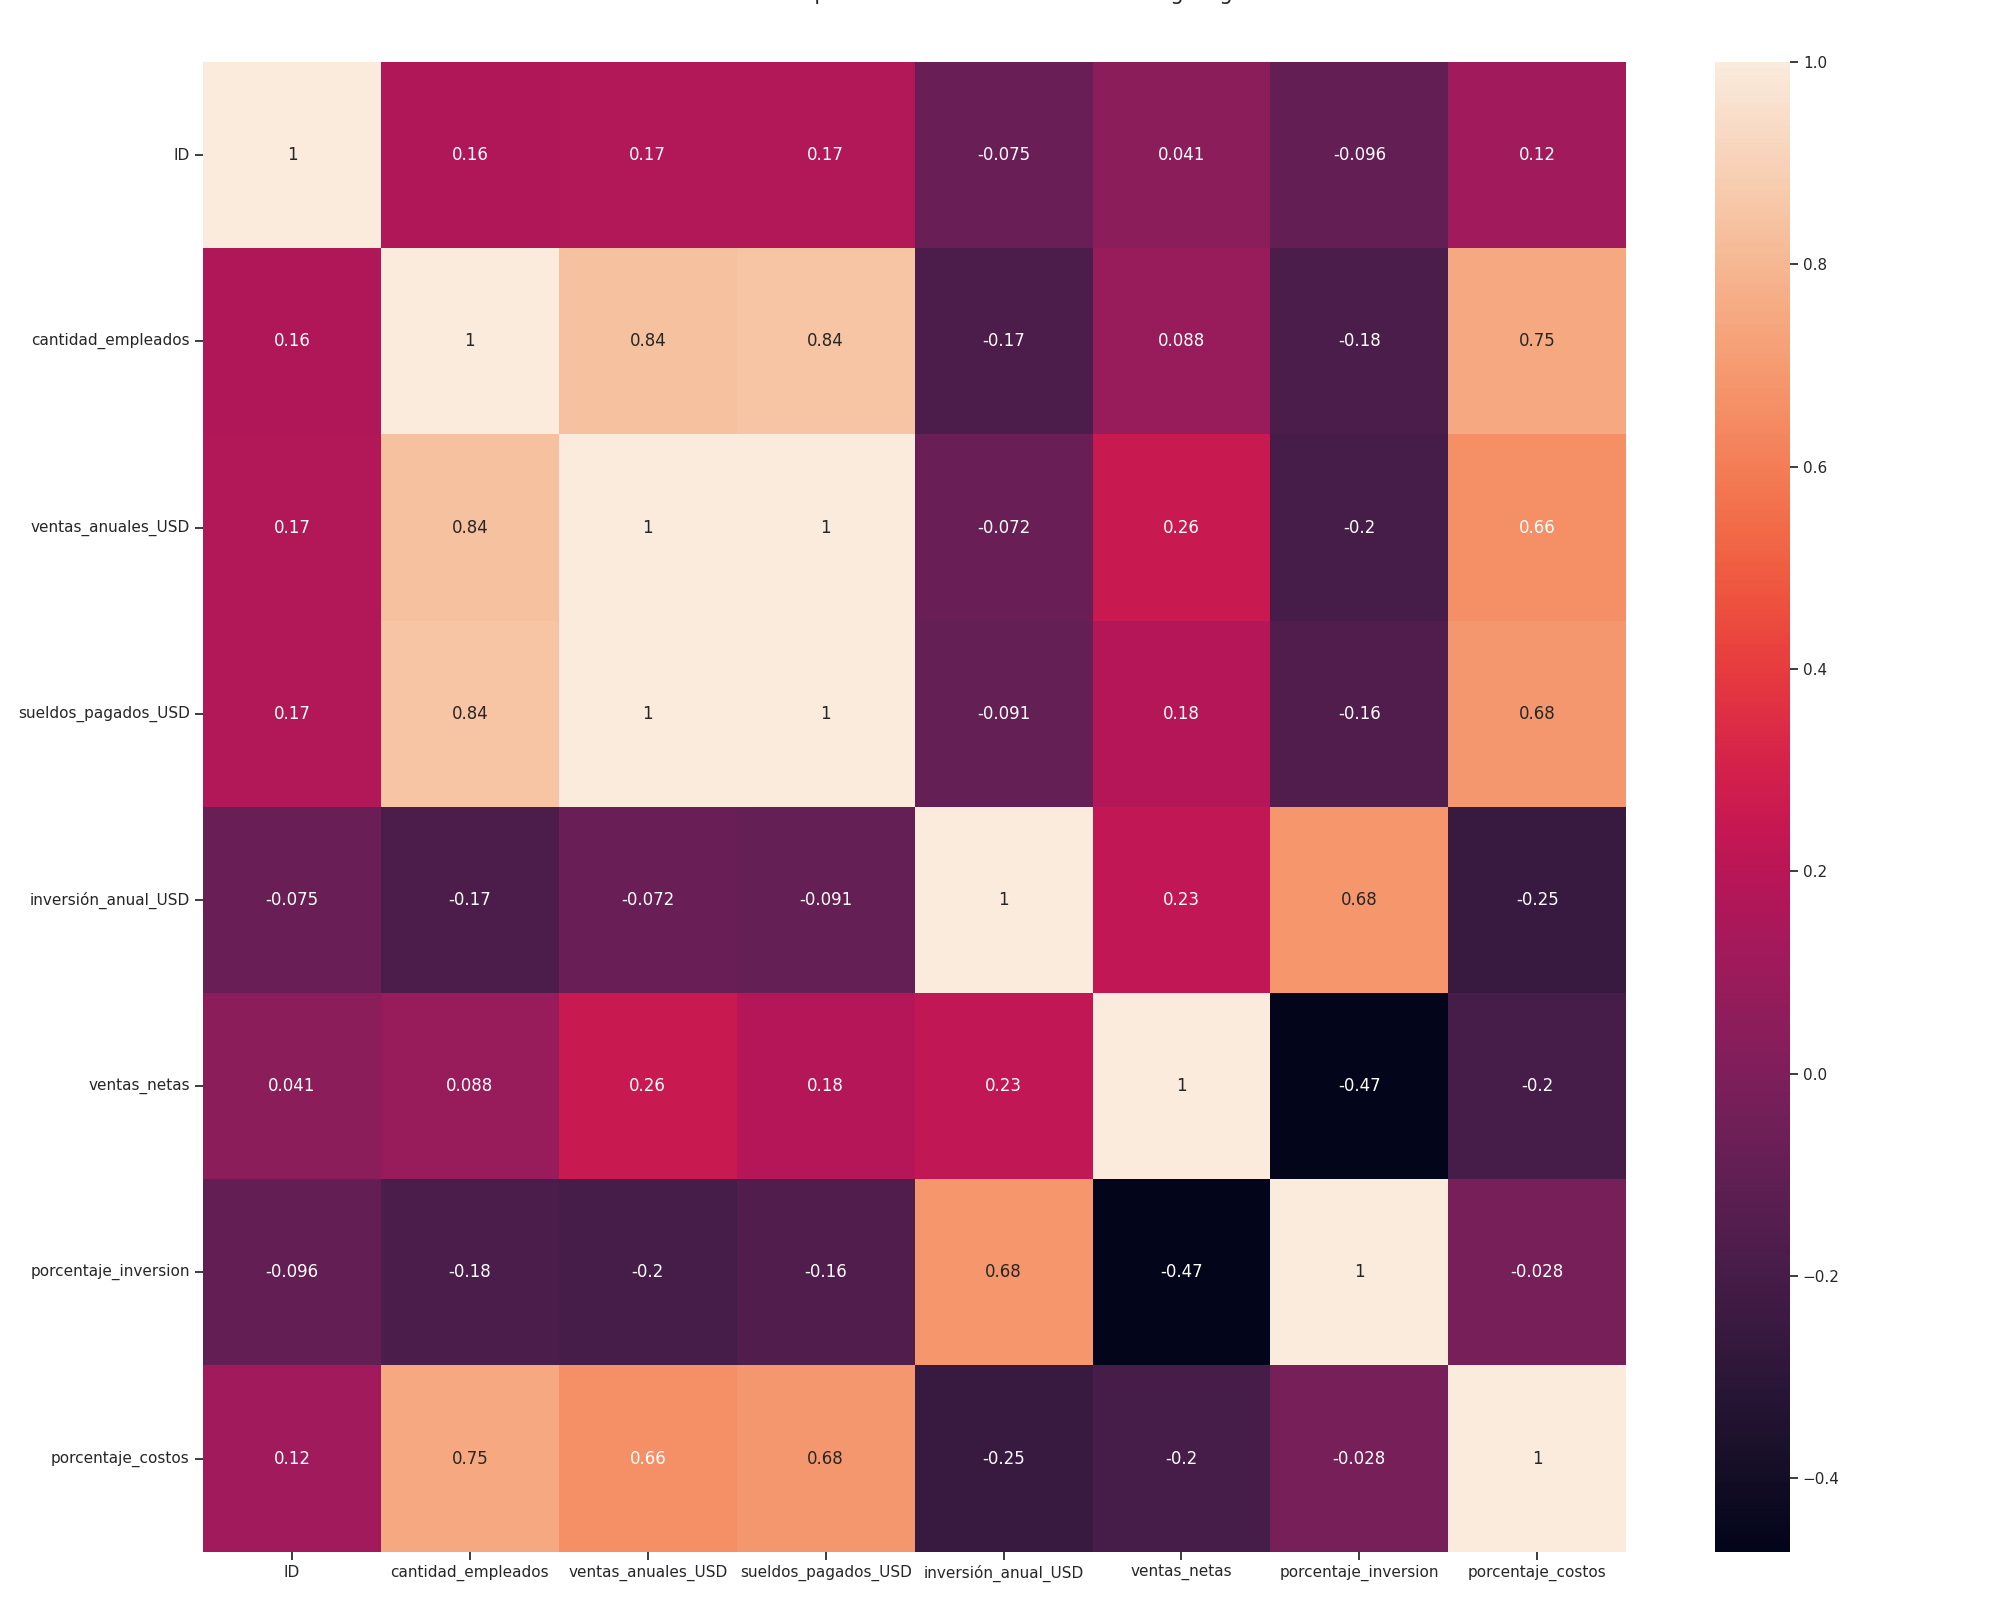

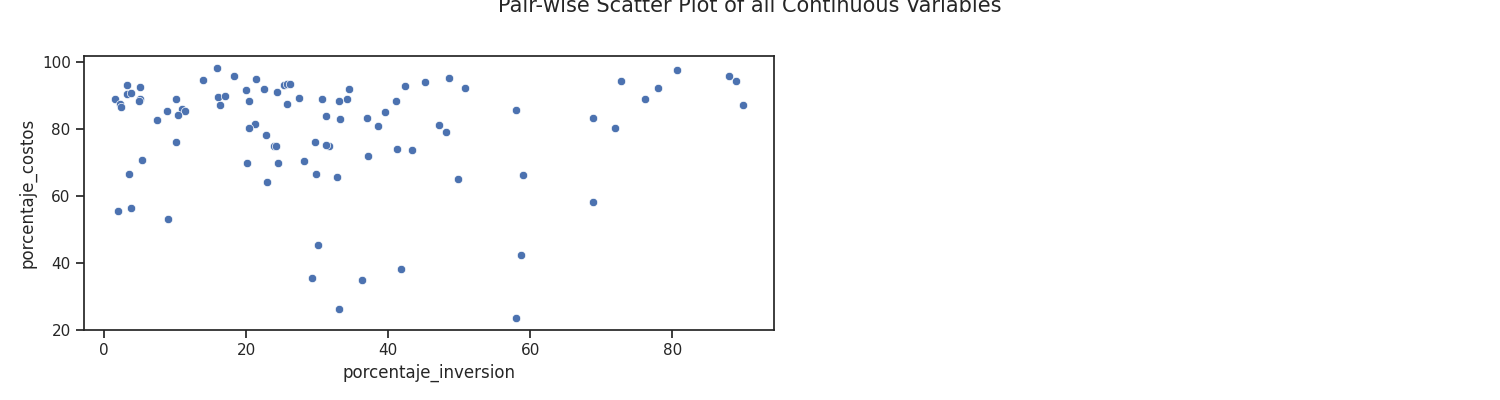

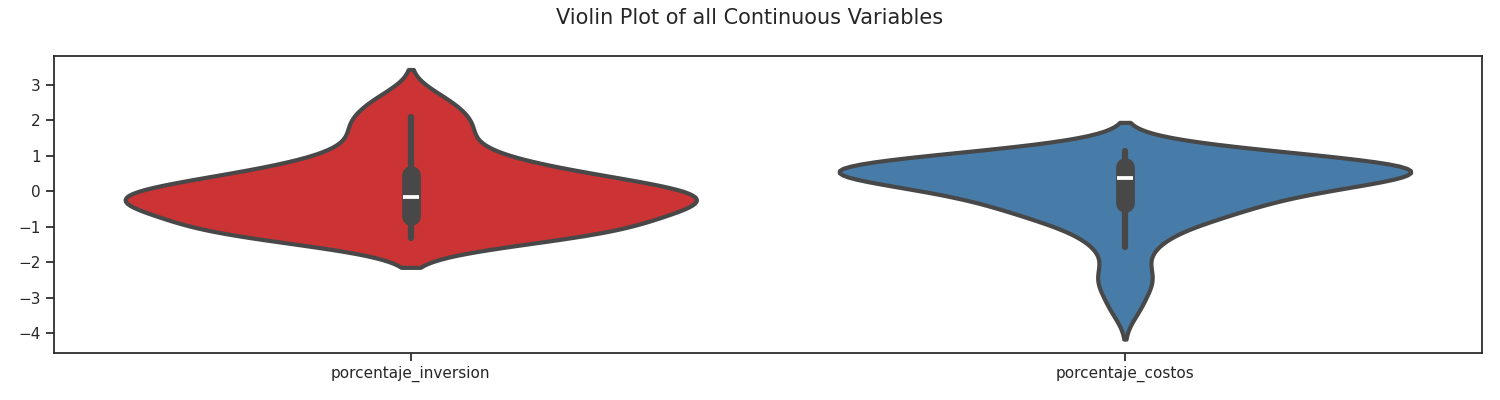

In [ ]:
#Analisis Exploratorio de Datos (EDA)
from autoviz.AutoViz_Class import AutoViz_Class
AV = AutoViz_Class()

res = AV.AutoViz(
    filename="",
    dfte=df,
    chart_format="png",          # fuerza PNG
    verbose=2,
    save_plot_dir="av_out"       # carpeta simple
)

import glob
from IPython.display import Image, display

imgs = sorted(glob.glob("av_out/**/*.png", recursive=True))
print(f"Se generaron {len(imgs)} gráficos")
for p in imgs[:8]:
    display(Image(filename=p))

In [ ]:
%matplotlib inline

#**6. ANALISIS BIVARIADO**

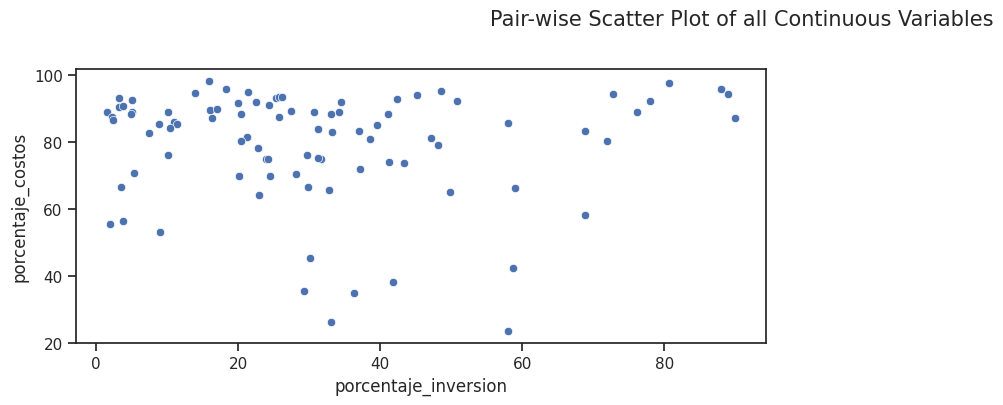

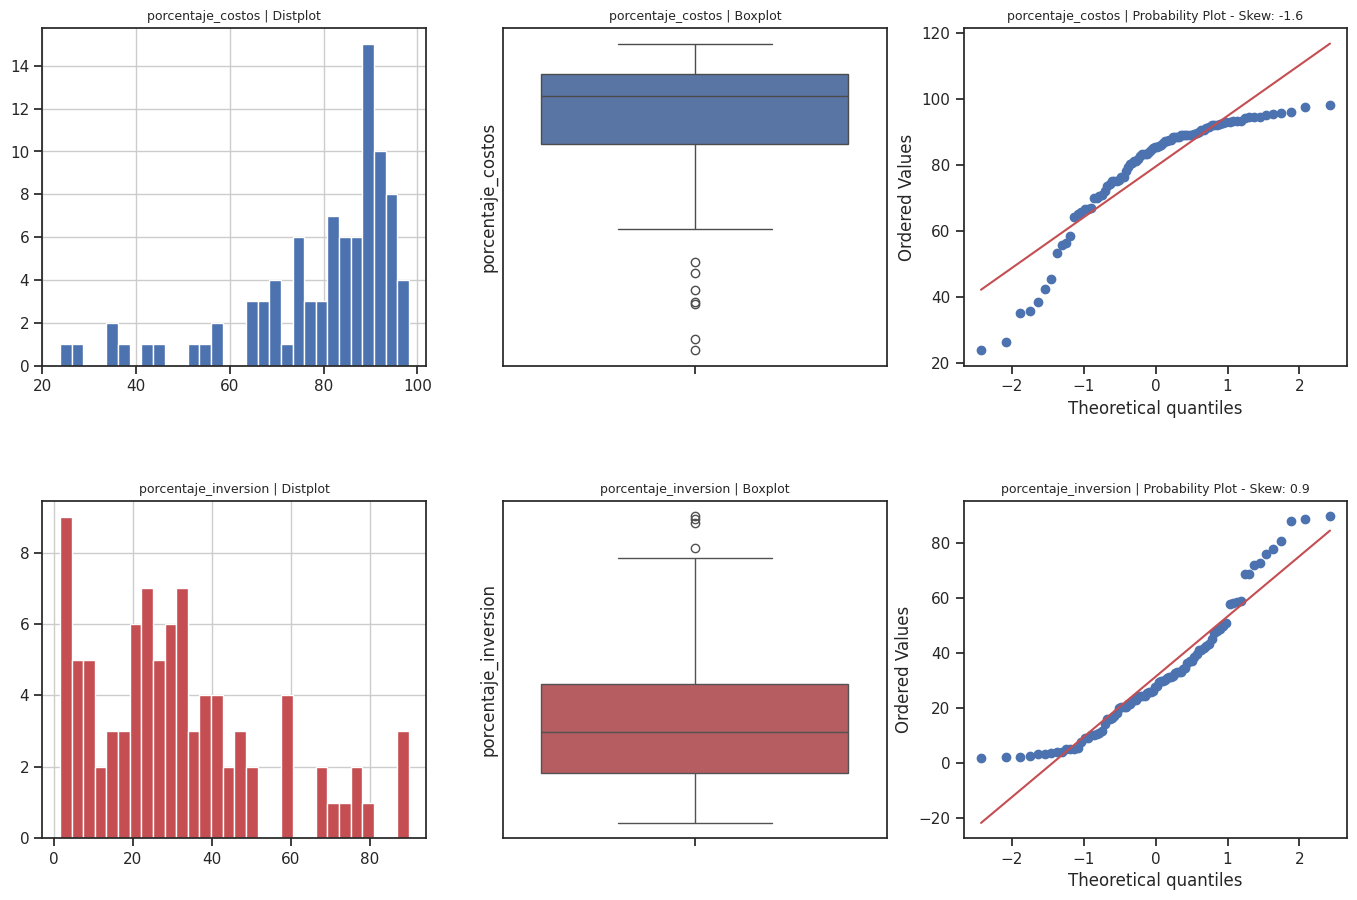

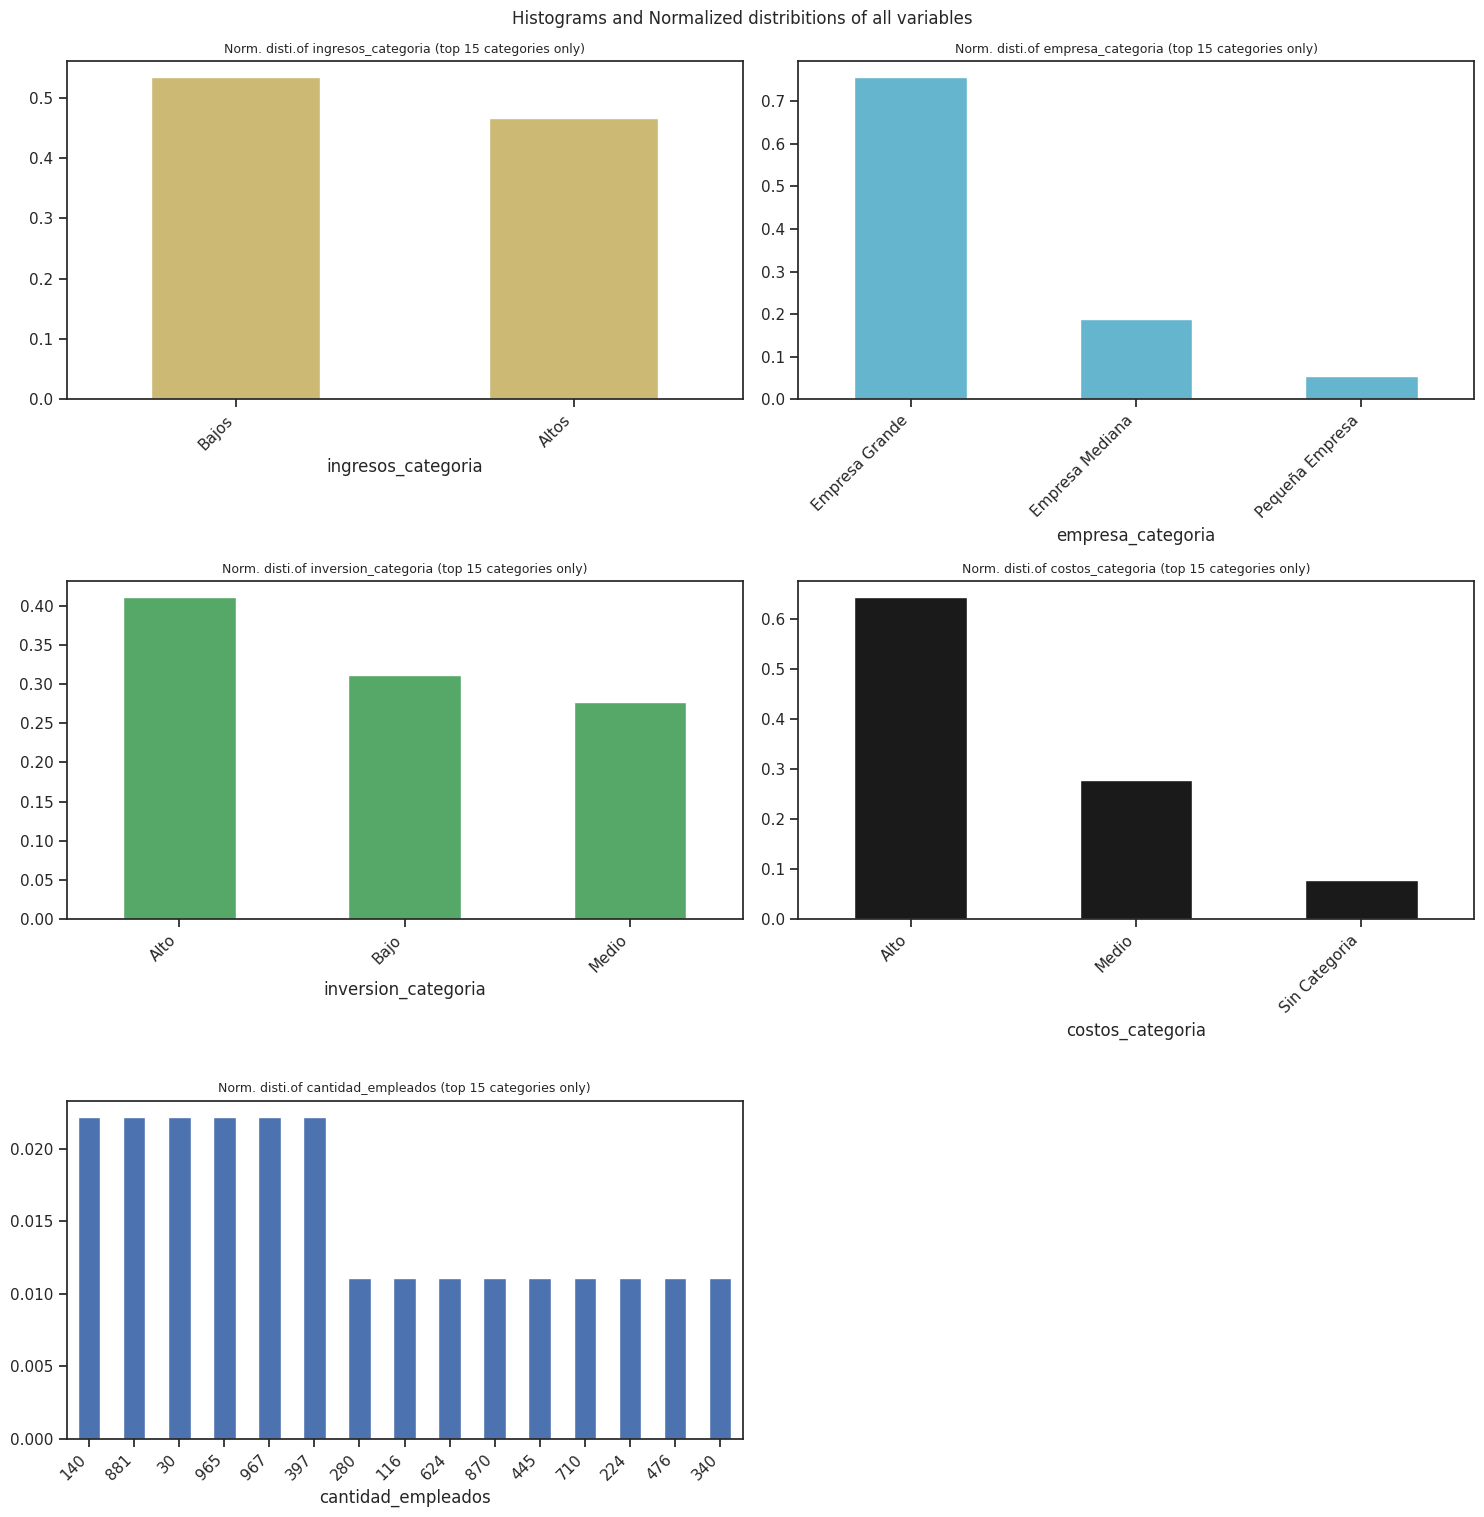

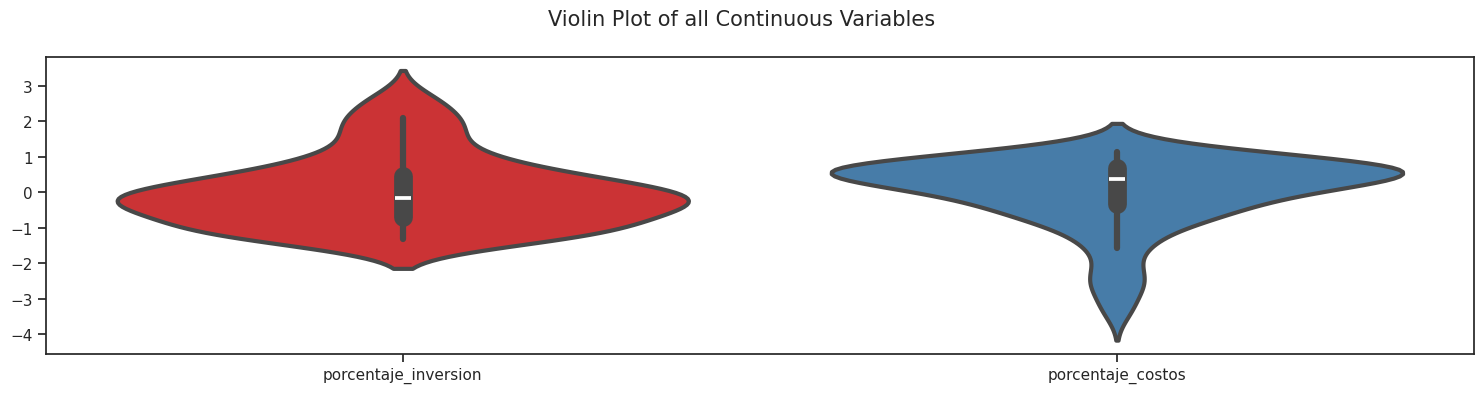

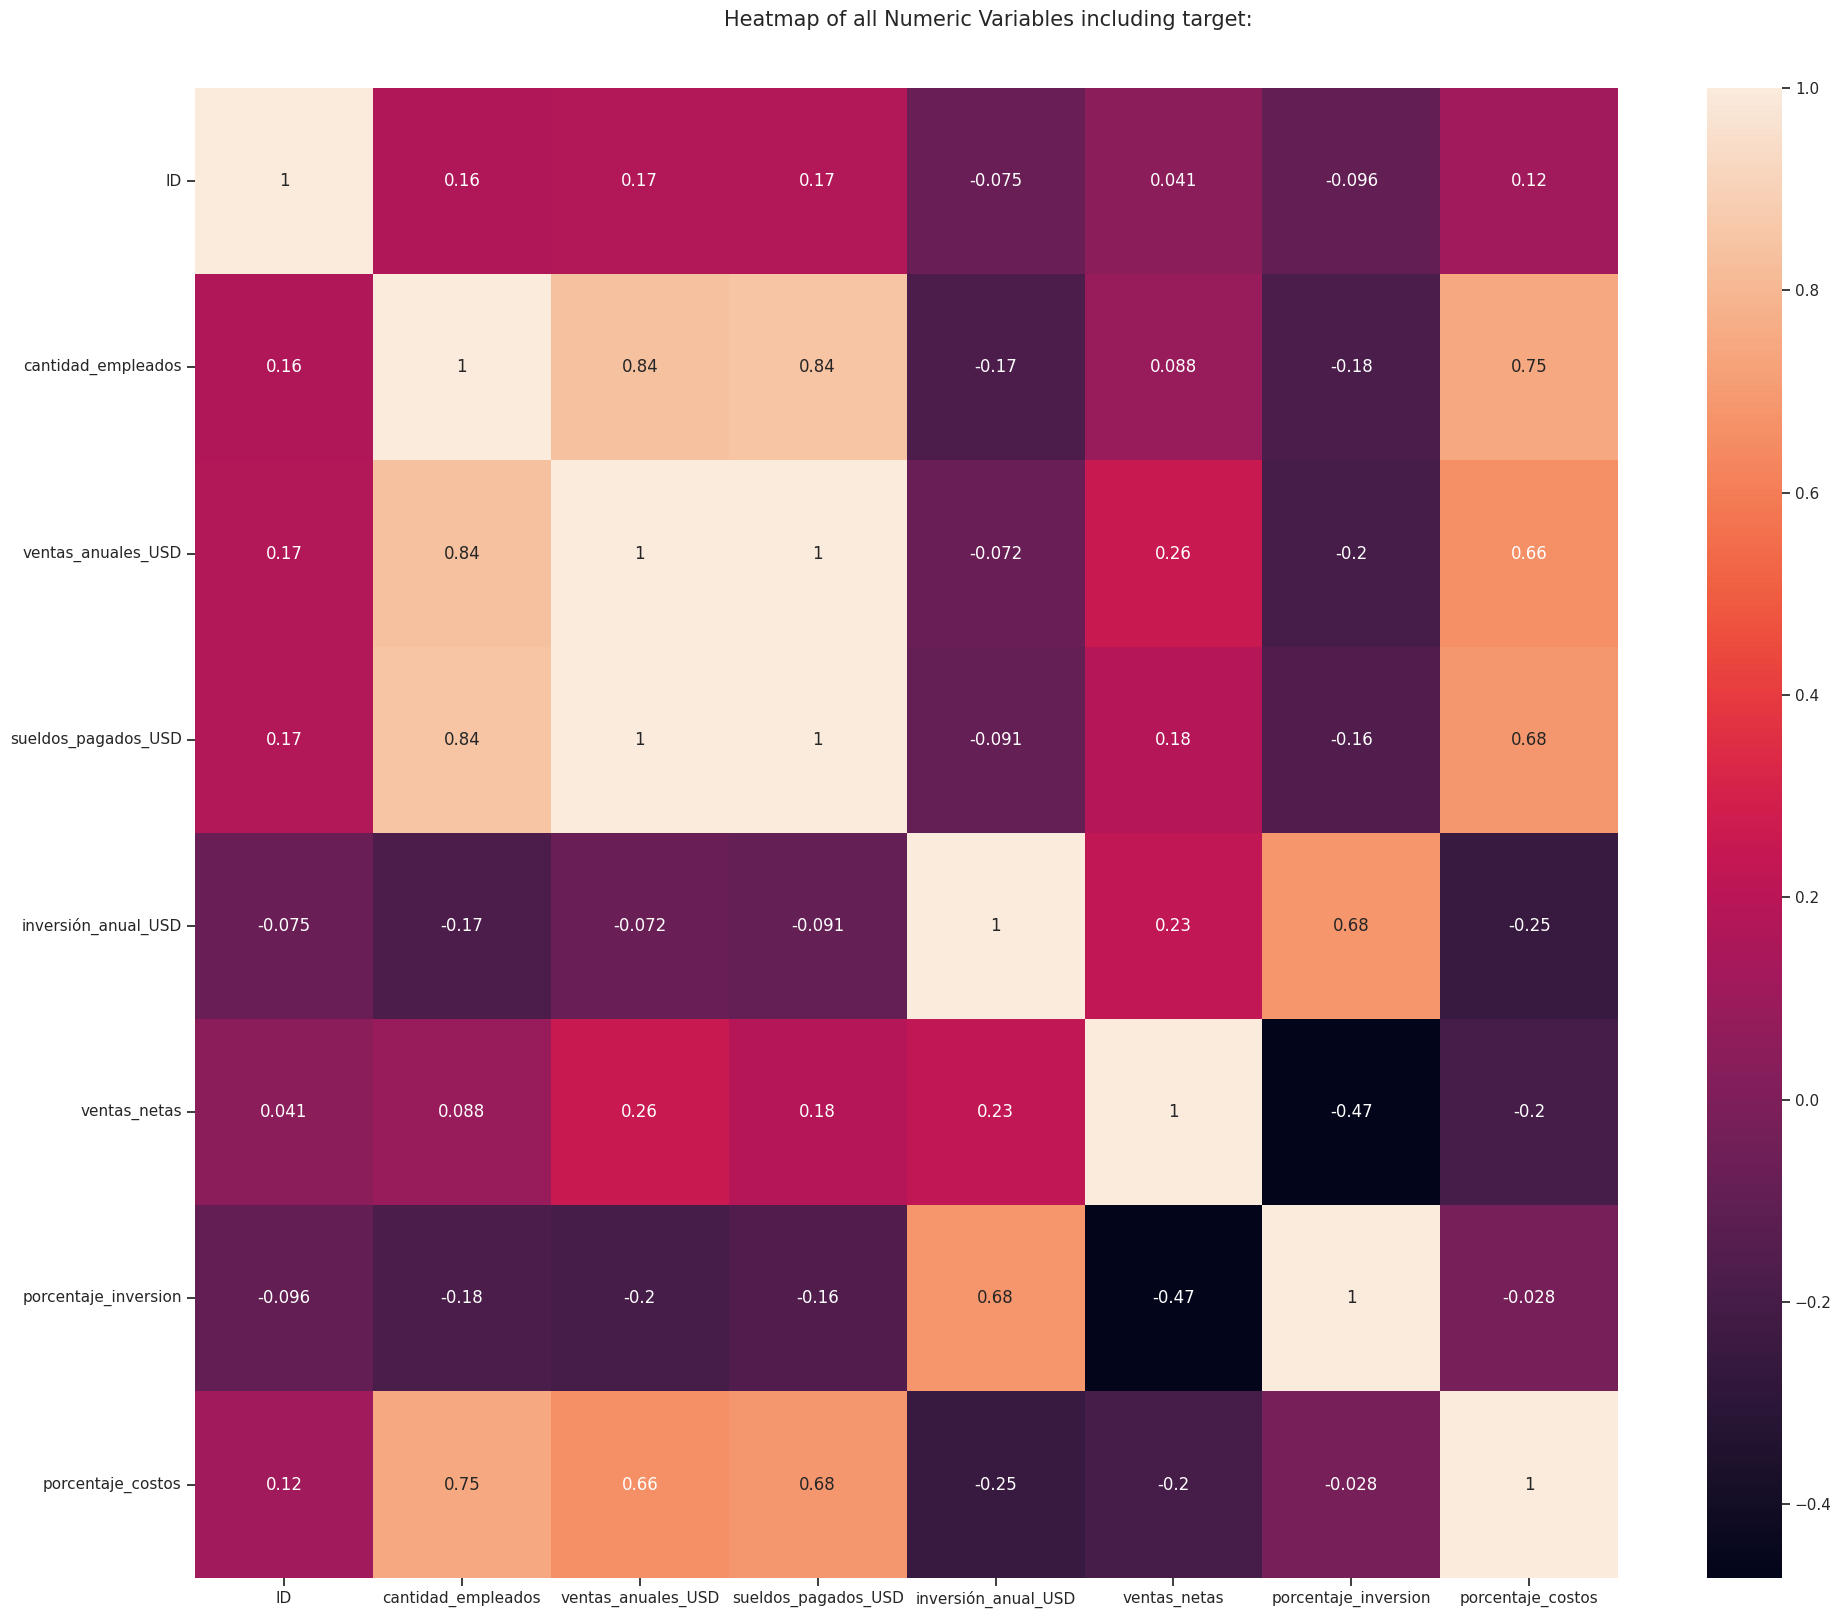

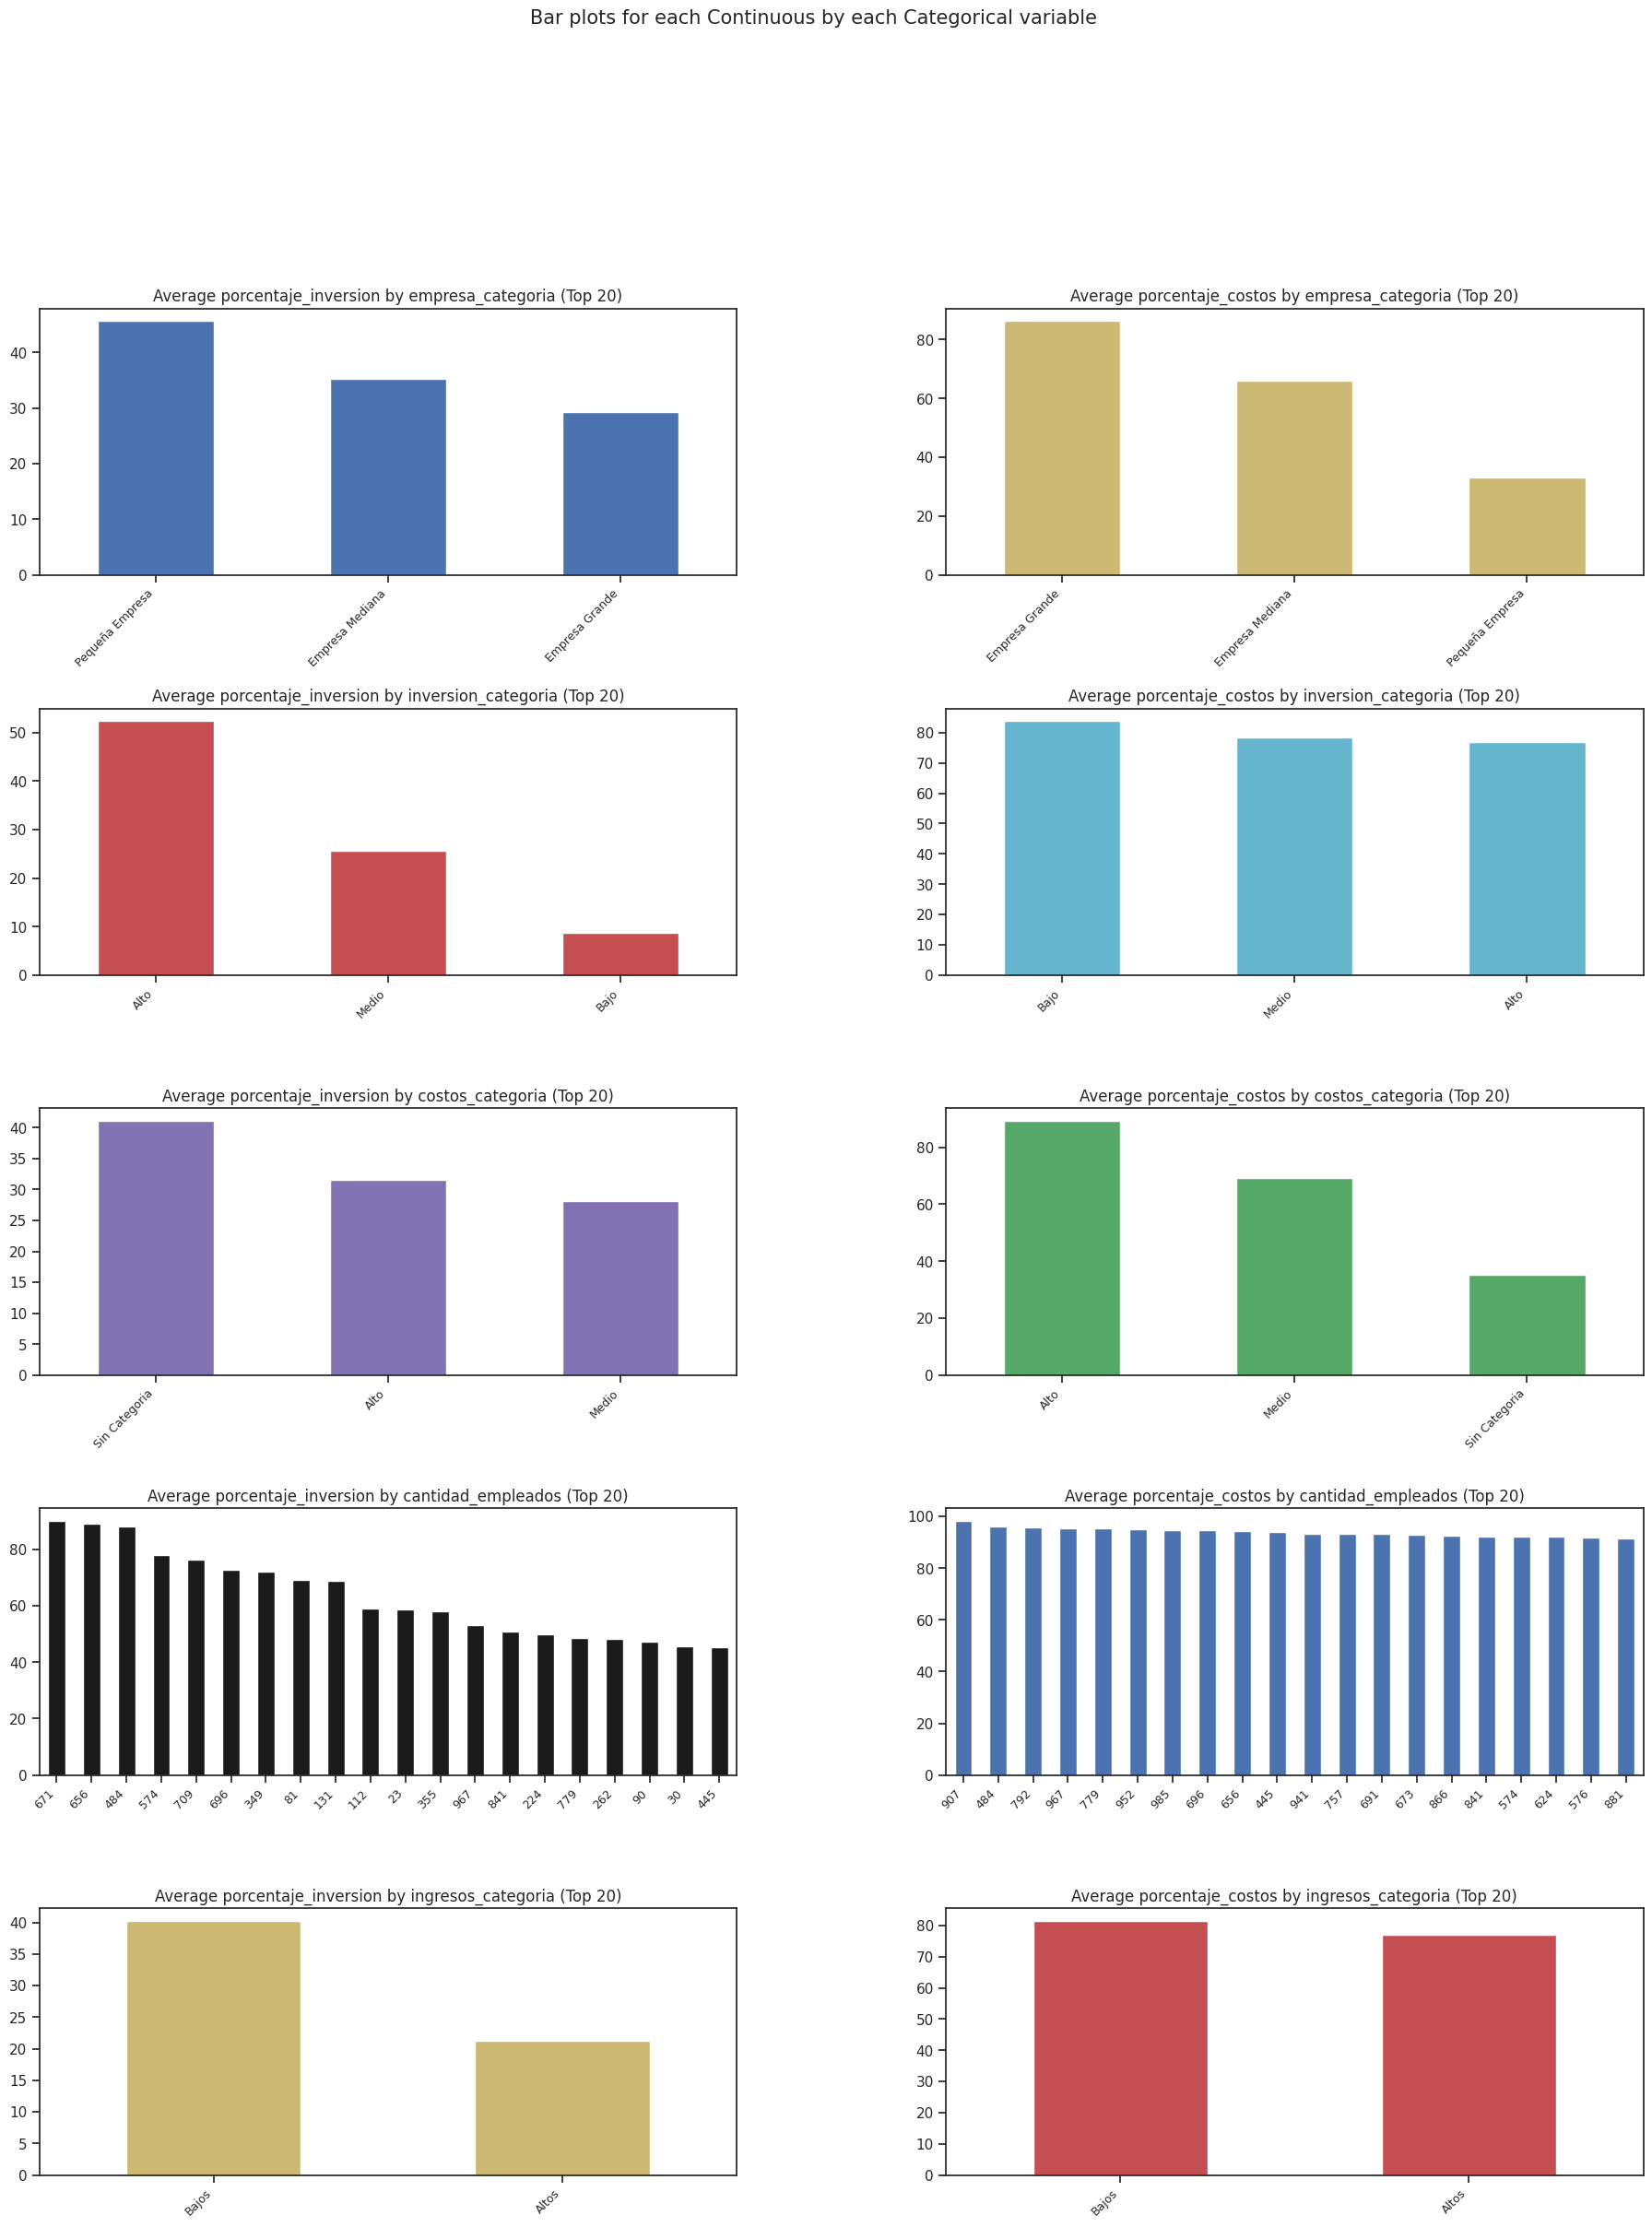

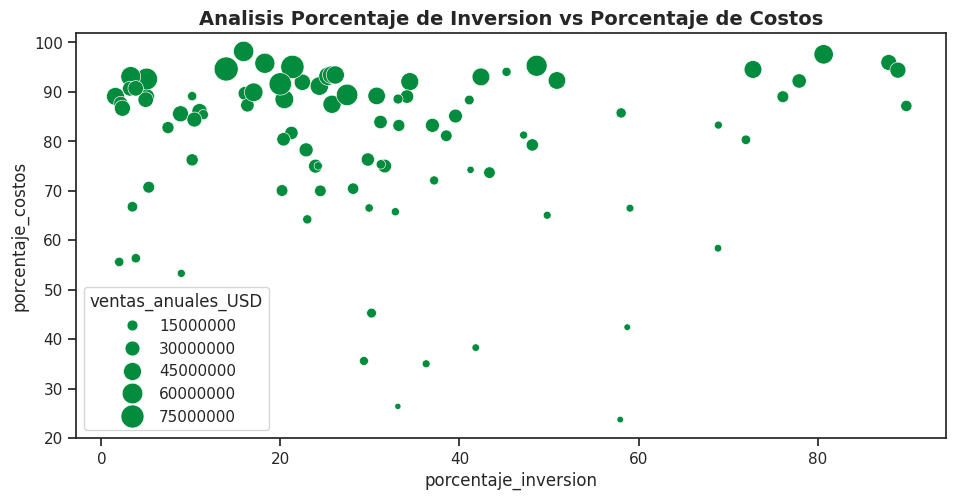

In [ ]:
#Analisis bivariado sobre las variables que relacionan las ventas anuales con los cotos y las ventas netas con las inversion
f, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(
    x="porcentaje_inversion",
    y="porcentaje_costos",
    size="ventas_anuales_USD",
    sizes=(20, 300),
    color="#038C3E",
    data=df)

plt.title("Analisis Porcentaje de Inversion vs Porcentaje de Costos", fontsize=14, weight="bold")
plt.show()

In [ ]:
#Analisis de correlacion entre las ventas netas y el porcentaje invertido
columns = ['ventas_netas','porcentaje_inversion']
ventas_inversion=df[columns].corr()
ventas_inversion

,ventas_netas,porcentaje_inversion
ventas_netas,1.000000,-0.472514
porcentaje_inversion,-0.472514,1.000000


<Axes: >

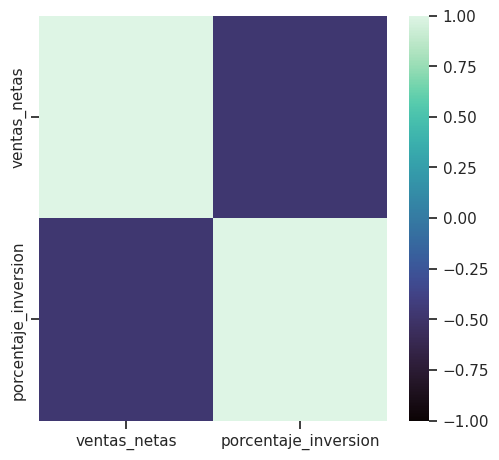

In [ ]:
#Grafico de estudio de correlacion Ventas e Inversion
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(ventas_inversion, cmap="mako",
            vmin=-1, vmax=1, center=0)

In [ ]:
#Analisis de correlacion entre las ventas anuales y los costos de los sueldos
columns = ['ventas_anuales_USD','sueldos_pagados_USD']
ventas_costos=df[columns].corr()
ventas_costos

,ventas_anuales_USD,sueldos_pagados_USD
ventas_anuales_USD,1.000000,0.997004
sueldos_pagados_USD,0.997004,1.000000


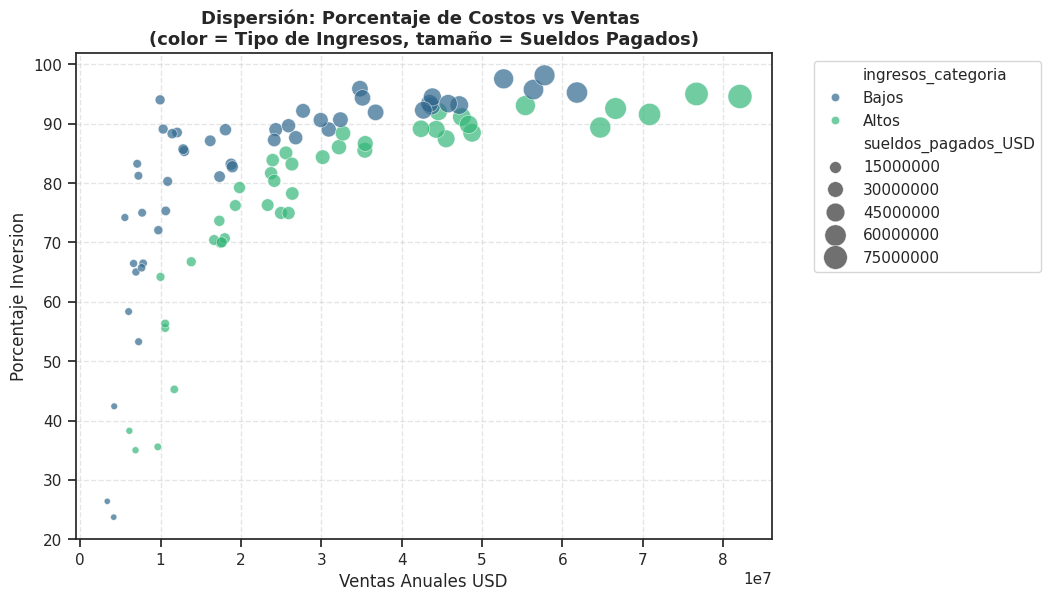

In [ ]:
#Grafico de estudio de correlacion y distribucion Ventas y Costos
plt.figure(figsize=(8,6))

# Scatter con seaborn
sns.scatterplot(
    data=df,
    x="ventas_anuales_USD",
    y="porcentaje_costos",
    hue="ingresos_categoria",          # colores por tipo de ingreso
    size="sueldos_pagados_USD",          # tamaño por Sueldos pagos
    sizes=(20, 300),         # rango de tamaños de los puntos
    alpha=0.7,               # transparencia para mejor visibilidad
    palette="viridis"           # paleta de colores
)

plt.title("Dispersión: Porcentaje de Costos vs Ventas \n(color = Tipo de Ingresos, tamaño = Sueldos Pagados)", fontsize=13, weight="bold")
plt.xlabel("Ventas Anuales USD")
plt.ylabel("Porcentaje Inversion")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # mover leyenda a la derecha
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

<Axes: >

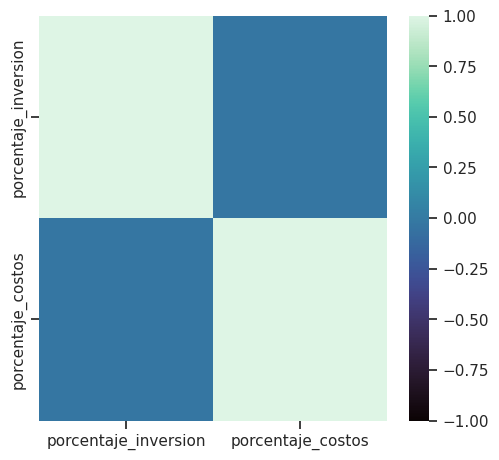

In [ ]:
#Analisis de correlacion entre las % inversion y % costos
columns = ['porcentaje_inversion','porcentaje_costos']
inversion_costos=df[columns].corr()
inversion_costos

#Grafico de estudio de correlacion
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(inversion_costos, cmap="mako",
            vmin=-1, vmax=1, center=0)

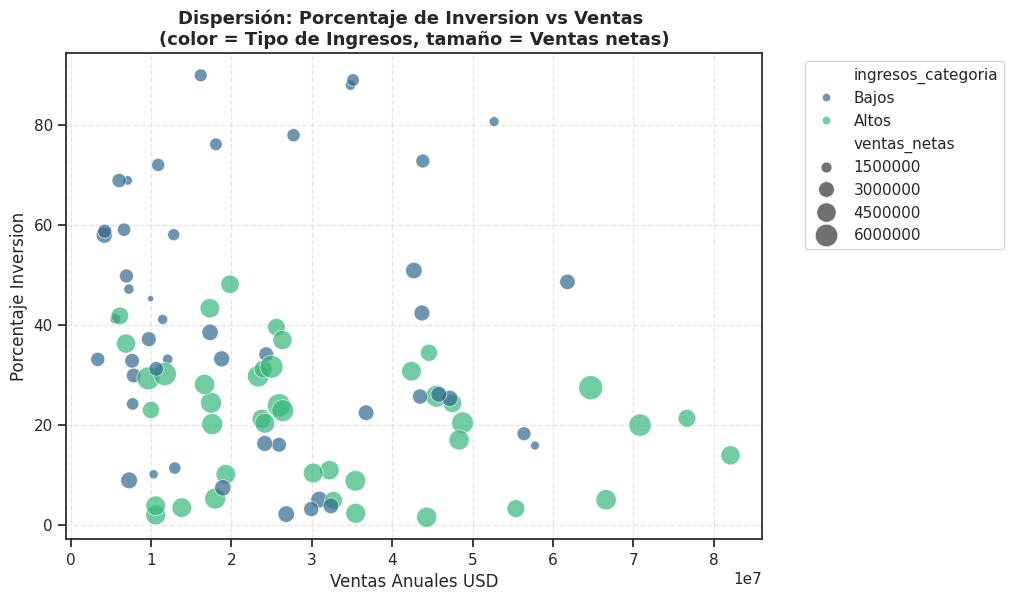

In [ ]:
#Distribucion de ventas e inversion
plt.figure(figsize=(8,6))

# Scatter con seaborn
sns.scatterplot(
    data=df,
    x="ventas_anuales_USD",
    y="porcentaje_inversion",
    hue="ingresos_categoria",          # colores por tipo de ingreso
    size="ventas_netas",          # tamaño por ingreso personal
    sizes=(20, 300),         # rango de tamaños de los puntos
    alpha=0.7,               # transparencia para mejor visibilidad
    palette="viridis"           # paleta de colores
)

plt.title("Dispersión: Porcentaje de Inversion vs Ventas \n(color = Tipo de Ingresos, tamaño = Ventas netas)", fontsize=13, weight="bold")
plt.xlabel("Ventas Anuales USD")
plt.ylabel("Porcentaje Inversion")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # mover leyenda a la derecha
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


#**7. ANALISIS DE COMPONENTES PRINCIPALES**

In [ ]:
df.describe()

,ID,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,porcentaje_inversion,porcentaje_costos
count,90.000000,90.000000,9.000000e+01,9.000000e+01,9.000000e+01,9.000000e+01,90.000000,90.000000
mean,45.500000,481.322222,2.700037e+07,2.346646e+07,9.535192e+05,3.533904e+06,31.336556,79.431778
std,26.124701,288.692318,1.868267e+07,1.836119e+07,5.840304e+05,1.469216e+06,22.414548,16.644131
min,1.000000,23.000000,3.375327e+06,8.907600e+05,7.195900e+04,5.942500e+05,1.570000,23.720000
25%,23.250000,251.500000,1.071081e+07,8.859636e+06,4.605710e+05,2.452317e+06,15.930000,73.790000
50%,45.500000,468.500000,2.405333e+07,1.941134e+07,9.181265e+05,3.305130e+06,27.785000,85.460000
75%,67.750000,709.750000,4.099482e+07,3.680443e+07,1.431523e+06,4.613923e+06,41.675000,90.675000
max,90.000000,985.000000,8.209224e+07,7.765642e+07,1.980267e+06,6.881436e+06,89.920000,98.160000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    90 non-null     int64  
 1   cantidad_empleados    90 non-null     int64  
 2   ventas_anuales_USD    90 non-null     int64  
 3   sueldos_pagados_USD   90 non-null     int64  
 4   inversión_anual_USD   90 non-null     int64  
 5   ventas_netas          90 non-null     int64  
 6   ingresos_categoria    90 non-null     object 
 7   empresa_categoria     90 non-null     object 
 8   porcentaje_inversion  90 non-null     float64
 9   inversion_categoria   90 non-null     object 
 10  porcentaje_costos     90 non-null     float64
 11  costos_categoria      90 non-null     object 
dtypes: float64(2), int64(6), object(4)
memory usage: 8.6+ KB


In [ ]:
profile = ProfileReport(df, title="Reporte de Perfilado", explorative=True)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 37.29it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#Borrar columnas que no sean numericas para la aplicacion de modelo
df = df.drop(columns= ['ingresos_categoria','empresa_categoria','inversion_categoria','costos_categoria','ID'])
#df = df.drop(columns=['ID'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cantidad_empleados    90 non-null     int64  
 1   ventas_anuales_USD    90 non-null     int64  
 2   sueldos_pagados_USD   90 non-null     int64  
 3   inversión_anual_USD   90 non-null     int64  
 4   ventas_netas          90 non-null     int64  
 5   porcentaje_inversion  90 non-null     float64
 6   porcentaje_costos     90 non-null     float64
dtypes: float64(2), int64(5)
memory usage: 5.1 KB


In [ ]:
#Columnas y filas de la matriz
df.shape

(90, 7)

In [ ]:
# Se nombra al dataframe como X para mantener la relacion con lo visto en clases de la Matriz
x= df
x_names= x.columns.tolist()
x.head()

,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,porcentaje_inversion,porcentaje_costos
0,112,6649054,4419184,1316702,2229870,59.05,66.46
1,445,9948595,9354345,268969,594250,45.26,94.03
2,870,30928216,27538110,172409,3390106,5.09,89.04
3,280,23329598,17800440,1646283,5529158,29.77,76.30
4,116,7275755,3876372,303618,3399383,8.93,53.28


In [ ]:
#Es necesario para la aplicacion de este modelo que el objeto sea tipo pandas
type(x)

pandas.core.frame.DataFrame

**CALCULO DE COMPONENTES PRINCIPALES SOBRE X**

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cantidad_empleados    90 non-null     int64  
 1   ventas_anuales_USD    90 non-null     int64  
 2   sueldos_pagados_USD   90 non-null     int64  
 3   inversión_anual_USD   90 non-null     int64  
 4   ventas_netas          90 non-null     int64  
 5   porcentaje_inversion  90 non-null     float64
 6   porcentaje_costos     90 non-null     float64
dtypes: float64(2), int64(5)
memory usage: 5.1 KB


In [ ]:
type(PCA())

sklearn.decomposition._pca.PCA

In [ ]:
#Si hubiese valores perdidos, es necesario aplicar al dataframe dropna para eliminarlos
PCA().fit(x)

PCA()

In [ ]:
pca_1 = PCA().fit(x)

In [ ]:
#Cada variable tiene su vairanza - Valores propios
pca_1.explained_variance_

array([6.85254384e+14, 3.10565305e+12, 3.15126792e+11, 2.29381642e+04,
       9.58012857e+01, 5.91716152e+01, 0.00000000e+00])

In [ ]:
np.set_printoptions(precision=2,suppress=True)
print(pca_1.explained_variance_)

[6.85e+14 3.11e+12 3.15e+11 2.29e+04 9.58e+01 5.92e+01 0.00e+00]


In [ ]:
#Calculamos la suma de valores propios para obtener la varianza total - La traza de la matriz
print(np.sum(pca_1.explained_variance_))

688675164017326.9


In [ ]:
#Porcentaje de la varianza de cada componente
varianza_explicada1 = pca_1.explained_variance_ratio_

np.set_printoptions(precision=3, suppress=True)
print(varianza_explicada1)

[0.995 0.005 0.    0.    0.    0.    0.   ]


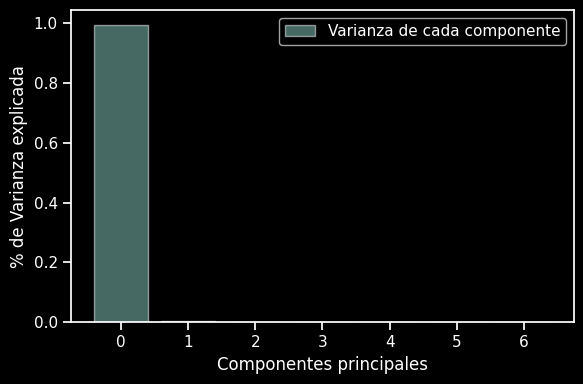

In [ ]:
with plt.style.context('dark_background'):
    plt.figure(figsize=(6, 4))
    plt.bar(range(7), varianza_explicada1, alpha=0.5, align='center', label='Varianza de cada componente')
    plt.ylabel('% de Varianza explicada')
    plt.xlabel('Componentes principales')
    plt.legend(loc='best')
    plt.tight_layout()

Text(0, 0.5, 'Varianza explicada acumulada')

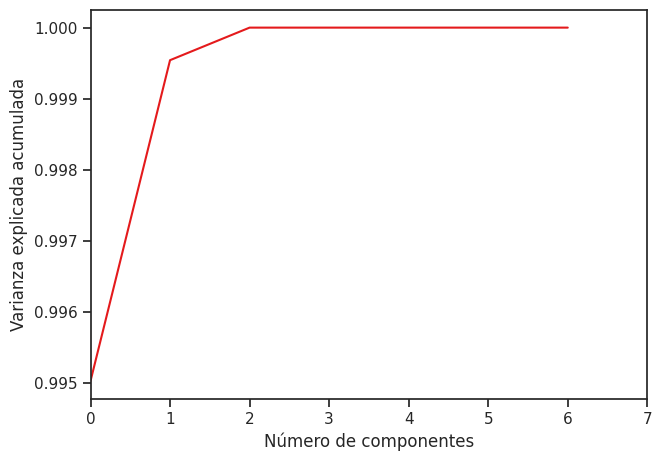

In [ ]:
# Variabilidad Acumulada
plt.plot(np.cumsum(pca_1.explained_variance_ratio_))
plt.xlim(0, 7)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')

In [ ]:
#Estandarizacion de datos
z_scales = StandardScaler()

x_z= DataFrame( z_scales.fit_transform(x), columns=x_names)
x_z.head(10)

,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,porcentaje_inversion,porcentaje_costos
0,-1.286461,-1.095418,-1.043178,0.625340,-0.892544,1.243331,-0.783727
1,-0.126521,-0.917819,-0.772890,-1.178681,-2.012041,0.624659,0.881993
2,1.353882,0.211418,0.222995,-1.344941,-0.098422,-1.177521,0.580508
3,-0.701266,-0.197581,-0.310316,1.192823,1.365648,-0.070282,-0.189215
4,-1.272527,-1.061685,-1.072906,-1.119021,-0.092073,-1.005244,-1.580034
5,-1.394443,-1.071052,-0.961387,-0.230590,-1.604874,1.686137,0.231293
6,0.796554,1.171122,1.077338,0.335881,1.428293,-0.488861,0.546070
7,-1.572091,-1.271627,-1.236422,-0.225011,-0.718217,0.080012,-3.204669
8,0.496990,0.946041,0.962080,0.459992,0.006555,0.139681,0.762366
9,-1.220278,-1.128633,-1.092404,1.336837,-0.699720,1.684342,-1.273111


In [ ]:
#Calculo nuevamente los componentes principales sobre los datos estandarizados

pca = PCA().fit(x_z)

In [ ]:
# Varianza de cada componente
print(pca.explained_variance_)

[3.547 1.652 1.373 0.28  0.172 0.055 0.   ]


In [ ]:
# Calculamos la suma de valores propios para obtener la varianza total - La traza de la matriz
print(np.sum(pca.explained_variance_))

7.078651685393258


In [ ]:
#Porcentaje de la varianza de cada componente
#Variable 1 Cantidad de Empleados explica el 50% de los componentes
#Variable 2 Ventas Anuales en USD explican el 23% de los componentes
#Variables 3 Sueldos Pagados en USD explica el 19% de los componentes, sumando esas 3 vairables ya podriamos explicar el 92% de la muestra
varianza_explicada2 = pca.explained_variance_ratio_

np.set_printoptions(precision=3, suppress=True)
print(varianza_explicada2)

[0.501 0.233 0.194 0.04  0.024 0.008 0.   ]


In [ ]:
np.sum(pca.explained_variance_ratio_)

np.float64(1.0)

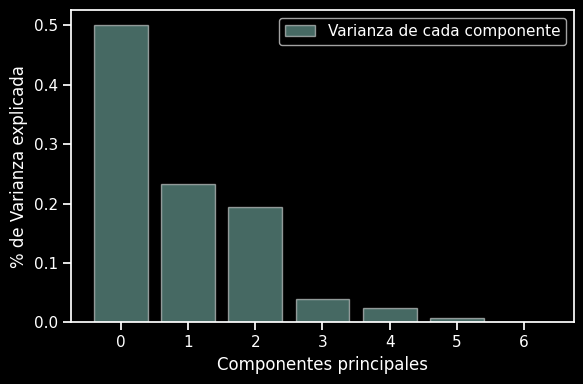

In [ ]:
with plt.style.context('dark_background'):
    plt.figure(figsize=(6, 4))
    plt.bar(range(7), varianza_explicada2, alpha=0.5, align='center', label='Varianza de cada componente')
    plt.ylabel('% de Varianza explicada')
    plt.xlabel('Componentes principales')
    plt.legend(loc='best')
    plt.tight_layout()

Text(0, 0.5, 'Varianza explicada acumulada')

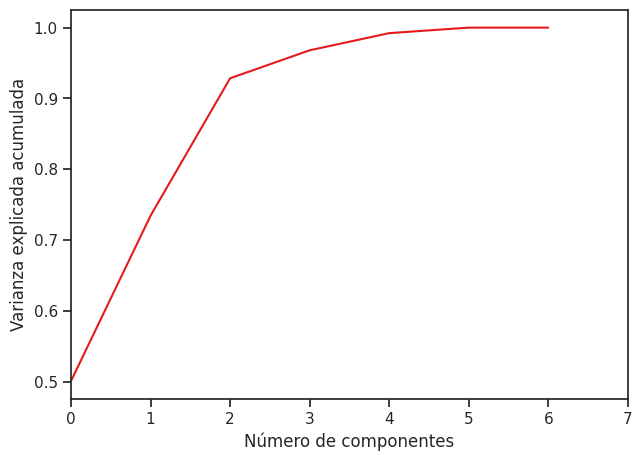

In [ ]:
# Variabilidad Acumulada
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlim(0, 7)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')

In [ ]:
#Coeficientes de las componentes (vectores propios)
pca.components_

DataFrame(pca.components_ ,index=["CP1","CP2","CP3","CP4","CP5","CP6","CP7"],columns=x_names)

,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,porcentaje_inversion,porcentaje_costos
CP1,4.938642e-01,0.505930,0.507581,-1.478178e-01,0.090068,-1.705407e-01,4.283078e-01
CP2,9.799153e-02,0.086787,0.115012,5.357156e-01,-0.333752,7.304620e-01,1.941165e-01
CP3,-1.733626e-02,0.173745,0.117430,5.615374e-01,0.741802,-3.032831e-02,-2.986774e-01
CP4,1.370537e-01,-0.376888,-0.409711,1.584679e-01,0.327733,-6.975377e-02,7.307002e-01
CP5,8.522300e-01,-0.239126,-0.237744,3.317344e-02,-0.069599,-3.074117e-04,-3.924997e-01
CP6,3.339944e-02,0.002730,-0.034310,-5.912884e-01,0.463506,6.569289e-01,-4.104065e-02
CP7,-6.633058e-17,0.712097,-0.699844,1.734723e-16,-0.056000,-4.996004e-16,-5.551115e-16


Text(0, 0.5, 'Componentes principales')

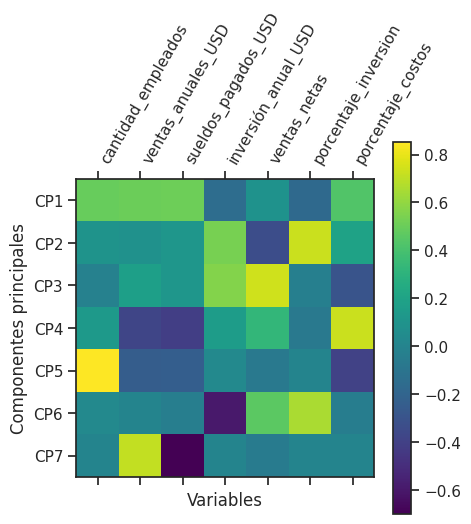

In [ ]:
#Analisis de los pesos de las variables de manera grafica
plt.matshow(pca.components_, cmap='viridis')
plt.yticks([0,1,2,3,4,5,6], ["CP1", "CP2", "CP3" , "CP4", "CP5", "CP6", "CP7"])
plt.colorbar()
plt.xticks(range(len(x_names)),
x_names, rotation=60, ha='left')
plt.xlabel("Variables")
plt.ylabel("Componentes principales")

In [ ]:
pca_scores = pca.fit_transform (x_z)
pca_df = pd.DataFrame(data=pca_scores, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5','PC6', 'PC7']);pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-2.439580,1.047856,-0.405086,-0.188879,-0.196313,0.055323,1.885875e-16
1,-0.654897,0.486641,-2.684819,0.399941,0.049960,0.158292,-1.724582e-16
2,1.528178,-1.258441,-0.926469,0.275438,0.784994,-0.009598,9.443005e-17
3,-0.726178,-0.026398,1.682890,0.608729,-0.457807,-0.124035,-5.300663e-16
4,-2.058369,-1.949985,-0.482656,-0.626603,0.014226,0.014871,1.000402e-15
5,-2.017479,1.348488,-1.715014,0.095324,-0.690958,0.474143,-3.956297e-16
6,1.928983,-0.244252,1.416026,0.180830,-0.159777,0.112700,-4.749596e-16
7,-3.464997,-0.851085,-0.043268,-1.847899,0.558577,-0.029324,1.671843e-15
8,1.447711,0.735713,0.299958,-0.060252,-0.315870,-0.222304,-1.322393e-17
9,-2.821308,1.589746,0.257577,-0.359533,0.081866,0.037605,1.058037e-16


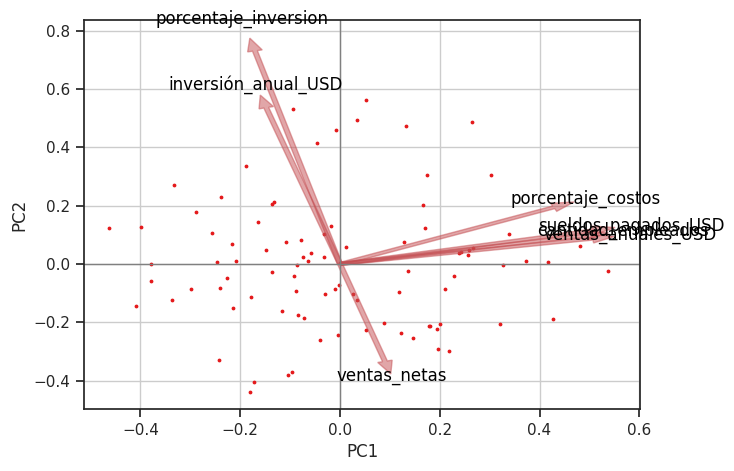

In [ ]:
# En este grafico podemos ver los vectores de las variables y como se relacionan entre ellas
# En este grafico vemos explicado con el componente 1 y 2 el 73% de la informacion de todo el conjunto de datos
# El largo del vector indica la participacion de la variable en la componente
# En este grafico a primera vist se puede apreciar que tanto las variables porcentaje de inversion y porcentaje de costos, presentan un angulo de 90°, es decir son ortogonales,
# son linealmente independientes, ya que los cambios de una no afecta a la otra.
# angulos agudos un alto nivel de correlacion, aca podemos interpretar que tanto ventas anuales, cantidad de empleados, sueldos pagos y porcentajes de costos, estan liealmente
# dependientes, el cambio de una afecta a las otras.
# Los puntos del grafico nos permite ver los scores de las empresas, podemos ver una alta dispersion de los mismos
def myplot(score, coeff, labels=x_names):
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())

    plt.scatter(xs * scalex, ys * scaley, s=3)

    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1],
                  color='r', alpha=0.5, width=0.01)
        if labels is None:
            plt.text(coeff[i,0]*1.15, coeff[i,1]*1.15,
                     "Var"+str(i+1), color='black',
                     ha='center', va='center')
        else:
            plt.text(coeff[i,0]*1.15, coeff[i,1]*1.15,
                     labels[i], color='black',
                     ha='center', va='center')

    plt.axhline(0, color='grey', lw=1)
    plt.axvline(0, color='grey', lw=1)
    plt.xlabel("PC{}".format(1))
    plt.ylabel("PC{}".format(2))
    plt.grid()

myplot(pca_scores[:,0:4], np.transpose(pca.components_[0:4, :]), list(x_names))
plt.show()



# **8. ANALISIS DE CONGLOMERADOS**

In [ ]:
# Detectamos atípicos variable por variable utilizando la fórmula de boxplot.


#Eliminamos los valores atípicos de cantidad de empleados
Q1g = x_z.cantidad_empleados.quantile(0.05)
Q3g = x_z.cantidad_empleados.quantile(0.95)
IQRg = Q3g - Q1g


# Eliminamos los valores atípicos de ventas anuales
Q1d = x_z.ventas_anuales_USD.quantile(0.05)
Q3d = x_z.ventas_anuales_USD.quantile(0.95)
IQRd = Q3d - Q1d


# Eliminamos los valores atípicos de la sueldos pagos
Q1 = x_z.sueldos_pagados_USD.quantile(0.05)
Q3 = x_z.sueldos_pagados_USD.quantile(0.95)
IQR = Q3 - Q1

#A la base de datos estandarizada le seleccionamos las observaciones que cumplen con los criterios de que los datos estén en el intervalo establecido
# otra posibilildad es en el criterio seleccionar los que están más allá de 3 veces el RI que se consideran extermos
x_z_df=x_z[(x_z.cantidad_empleados >= Q1g - 1.5*IQR)&(x_z.cantidad_empleados <= Q3g + 1.5*IQR)&(x_z.ventas_anuales_USD >= Q1d - 1.5*IQRg) & (x_z.ventas_anuales_USD <= Q3d + 1.5*IQRd)&(x_z.sueldos_pagados_USD >= Q1 - 1.5*IQR) & (x_z.sueldos_pagados_USD <= Q3 + 1.5*IQR)]
print(x_z_df.shape)

x_z_df.head()

(90, 7)


,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,porcentaje_inversion,porcentaje_costos
0,-1.286461,-1.095418,-1.043178,0.625340,-0.892544,1.243331,-0.783727
1,-0.126521,-0.917819,-0.772890,-1.178681,-2.012041,0.624659,0.881993
2,1.353882,0.211418,0.222995,-1.344941,-0.098422,-1.177521,0.580508
3,-0.701266,-0.197581,-0.310316,1.192823,1.365648,-0.070282,-0.189215
4,-1.272527,-1.061685,-1.072906,-1.119021,-0.092073,-1.005244,-1.580034


In [ ]:
# x_z es la nuestra base de datos con variables numericas y estandarizada
df= x_z
df= df.to_numpy() # para transformarlo en array

# Matriz de varianzas y covarianzas
covariance  = np.cov(df , rowvar=False)
covariance

array([[ 1.011,  0.847,  0.854, -0.176,  0.089, -0.181,  0.759],
       [ 0.847,  1.011,  1.008, -0.073,  0.259, -0.201,  0.664],
       [ 0.854,  1.008,  1.011, -0.092,  0.183, -0.166,  0.692],
       [-0.176, -0.073, -0.092,  1.011,  0.228,  0.688, -0.252],
       [ 0.089,  0.259,  0.183,  0.228,  1.011, -0.478, -0.204],
       [-0.181, -0.201, -0.166,  0.688, -0.478,  1.011, -0.028],
       [ 0.759,  0.664,  0.692, -0.252, -0.204, -0.028,  1.011]])

In [ ]:
# Invesa de la matriz de covarianzas
covariance_pm1 = np.linalg.inv(covariance )
covariance_pm1

array([[ 4.395e+00, -5.933e+00,  2.967e+00, -1.118e-01,  3.708e-01,
         3.823e-01, -1.541e+00],
       [-5.386e+00, -4.616e+15,  4.536e+15,  1.365e+00,  3.630e+14,
        -1.405e+00,  4.138e+00],
       [ 2.692e+00,  4.536e+15, -4.458e+15, -1.394e+00, -3.567e+14,
         1.233e+00, -4.917e+00],
       [-1.118e-01,  6.159e-01, -6.585e-01,  6.849e+00, -4.674e+00,
        -6.855e+00,  7.014e-01],
       [ 4.007e-01,  3.630e+14, -3.567e+14, -4.733e+00, -2.854e+13,
         5.396e+00,  1.233e-01],
       [ 3.823e-01, -6.193e-01,  4.610e-01, -6.855e+00,  5.334e+00,
         8.179e+00, -5.989e-01],
       [-1.541e+00,  4.694e+00, -5.464e+00,  7.014e-01,  7.958e-02,
        -5.989e-01,  2.977e+00]])

In [ ]:
# Centro de los datos
centerpoint = np.mean(df , axis=0)
centerpoint

array([ 0., -0., -0.,  0., -0.,  0.,  0.])

In [ ]:
#from scipy.spatial import distance
#distance.mahalanobis()para calcular distancia entre dos puntos

# Distancia al centro de los datos
distances = []
for i, val in enumerate(df):
      p1 = val
      p2 = centerpoint
      distance = (p1-p2) @ covariance_pm1 @ (p1-p2)
      distances.append(distance)
distances = np.array(distances)
print(distances.shape)


(90,)


In [ ]:
# Valor crítico de la Distribución Chi-Sqaure Distribution para detectar atípicos
from scipy.stats import chi2
cutoff = chi2.ppf(0.95, df.shape[1])
cutoff

np.float64(14.067140449340169)

In [ ]:
# Inicador de atipicos
outlierIndexes = np.where(distances > cutoff )
print('------------------------------')
print('--- Indicador de atípicos ----')
print('------------------------------')
print(outlierIndexes)
print('------------------------------')
print('---Observacione atípicas------')
print('------------------------------')
print(df[ distances > cutoff , :])
np.delete(df,outlierIndexes)

------------------------------
--- Indicador de atípicos ----
------------------------------
(array([ 7, 39, 50, 61, 82]),)
------------------------------
---Observacione atípicas------
------------------------------
[[-1.572 -1.272 -1.236 -0.225 -0.718  0.08  -3.205]
 [ 0.009  0.42   0.543  0.513 -1.445  2.54   0.996]
 [ 1.692  1.383  1.53   0.139 -1.541  2.214  1.096]
 [-1.572 -1.228 -1.231  1.542 -0.235  1.194 -3.366]
 [ 1.64   2.674  2.705 -0.238  0.196 -0.448  0.942]]


array([-1.286, -1.095, -1.043,  0.625, -0.893,  1.243, -0.784, -0.918,
       -0.773, -1.179, -2.012,  0.625,  0.882,  1.354,  0.211,  0.223,
       -1.345, -0.098, -1.178,  0.581, -0.701, -0.198, -0.31 ,  1.193,
        1.366, -0.07 , -0.189, -1.273, -1.062, -1.073, -1.119, -0.092,
       -1.005, -1.58 , -1.394, -1.071, -0.961, -0.231,  1.686,  0.231,
        0.797,  1.171,  1.077,  0.336,  1.428, -0.489,  0.546, -1.572,
       -1.236, -0.225, -0.718,  0.08 , -3.205,  0.497,  0.946,  0.962,
        0.46 ,  0.007,  0.762, -1.22 , -1.129, -1.092,  1.337, -0.7  ,
        1.684, -1.273, -0.019, -0.513, -0.616,  0.569,  1.174, -0.309,
       -0.572, -0.896, -1.08 , -1.038,  0.44 , -0.757, -0.87 , -0.492,
       -0.175, -0.223, -0.05 ,  0.561, -0.453,  0.135, -0.046, -0.075,
       -0.092,  0.958,  0.194,  0.369,  0.342, -1.339, -1.031, -1.   ,
       -0.289, -0.621, -0.064, -0.781, -0.346, -0.164, -0.185,  0.432,
        0.225, -0.007,  0.269, -1.297, -0.933, -1.097,  1.502,  1.843,
      

In [ ]:
# Lista de valores atipicos
print(list(outlierIndexes))

[array([ 7, 39, 50, 61, 82])]


In [ ]:
df.shape

(90, 7)

In [ ]:
#Borramos los atípicos de la base original

# Convert the NumPy array back to a DataFrame
df = pd.DataFrame(df, columns=x_names)

# Drop the outliers
df = df.drop(df.index[(outlierIndexes)], axis=0)

# Convert back to NumPy array for subsequent calculations
df = df.to_numpy()

# Nueva base de datos sin datos atipicos
df.shape

(80, 7)

In [ ]:
#Estandarizamos los valores de la base df ( sin datos atipicos calculados con la distancia de mahalanobis)

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled.shape
df_scaled = pd.DataFrame(df_scaled)
df_scaled.columns = ['cantidad_empleados', 'ventas_anuales_USD', 'sueldos_pagados_USD','inversión_anual_USD',	'ventas_netas',	'porcentaje_inversion',	'porcentaje_costos']
df_scaled.head()

,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,porcentaje_inversion,porcentaje_costos
0,-1.327773,-1.122193,-1.067888,0.637509,-0.937904,1.378474,-0.942556
1,-0.128430,-0.936305,-0.783791,-1.143622,-2.058972,0.726956,0.959724
2,1.402263,0.245634,0.262972,-1.307773,-0.142668,-1.170904,0.615423
3,-0.722699,-0.182453,-0.297585,1.197792,1.323456,-0.004880,-0.263614
4,-1.313367,-1.086886,-1.099136,-1.084720,-0.136310,-0.989481,-1.851952


In [ ]:
df_scaled.shape

(85, 7)

Clasificación no supervisada: cluster jerárquico

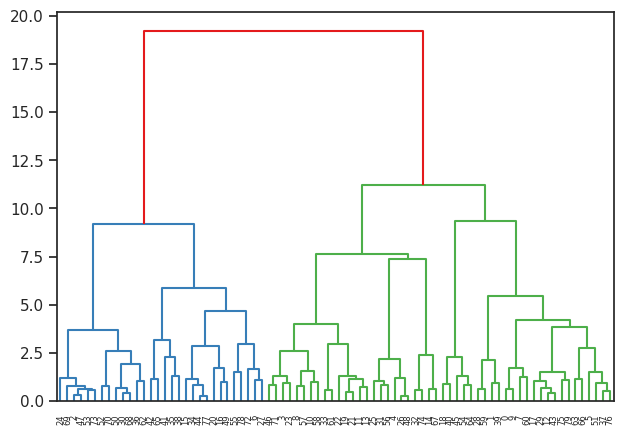

In [ ]:
#Formas de una la medida linkeage (base,metodo/algoritmo,medida de distancia) - la forma para utilizar el metodo de clasificacion
#Metodo de Ward y distancia euclidea
# Podemos visualizar la cantidad de grupos que se forman con la combinacion de empresas
mergings = linkage(df, method="ward", metric='euclidean')
mergings1 = linkage(df_scaled, method="ward", metric='euclidean')
mergings2 = linkage(x_z_df, method="ward", metric='euclidean')

dendrogram(mergings)
plt.show()

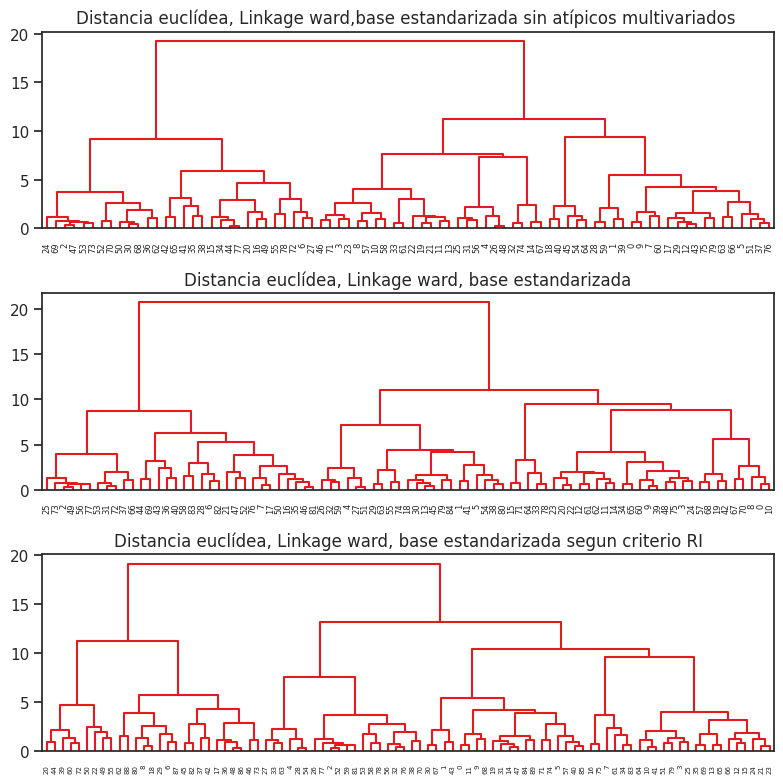

In [ ]:
#Dendrogramas con distintas bases (tbien se podría hacer con distintos métodos)  tarda mucho esta rutina
# ==============================================================================
fig, axs = plt.subplots(3, 1, figsize=(8, 8))
dendrogram(mergings, color_threshold=0, ax=axs[0])
axs[0].set_title("Distancia euclídea, Linkage ward,base estandarizada sin atípicos multivariados ")
dendrogram(mergings1, color_threshold=0, ax=axs[1])
axs[1].set_title("Distancia euclídea, Linkage ward, base estandarizada")
dendrogram(mergings2, color_threshold=0, ax=axs[2])
axs[2].set_title("Distancia euclídea, Linkage ward, base estandarizada segun criterio RI")

plt.tight_layout()

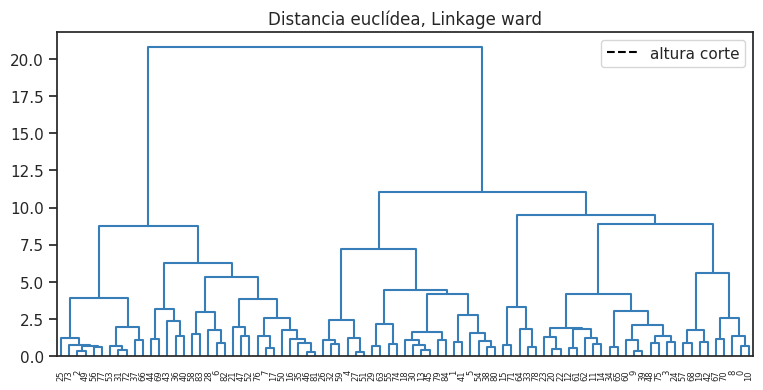

In [ ]:
## para cortar el dendrograma ( altura del corte es la distancia ultraméttica : eje de las ordenadas del gráfico). Seleccionamos el primero
mergings = linkage(df_scaled, method="ward", metric='euclidean')

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
altura_corte = 25
dendrogram(mergings, color_threshold=altura_corte, ax=ax)
ax.set_title("Distancia euclídea, Linkage ward")
ax.axhline(y=altura_corte, c = 'black', linestyle='--', label='altura corte')
ax.legend();

Selección del número de grupos

In [ ]:
#
df_x = pd.DataFrame(x)
df_x.head()

,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,porcentaje_inversion,porcentaje_costos
0,112,6649054,4419184,1316702,2229870,59.05,66.46
1,445,9948595,9354345,268969,594250,45.26,94.03
2,870,30928216,27538110,172409,3390106,5.09,89.04
3,280,23329598,17800440,1646283,5529158,29.77,76.30
4,116,7275755,3876372,303618,3399383,8.93,53.28


In [ ]:
# Asignar el grupo a cada fila
df_x['g1'] = fcluster(mergings2, 2, criterion = 'maxclust')
pd.value_counts(df_x['g1'])

,count
g1,
2,63
1,27


In [ ]:
df_x['g2'] = fcluster(mergings2, 3, criterion = 'maxclust')
pd.value_counts(df_x['g2'])

,count
g2,
3,43
1,27
2,20


In [ ]:
#Agregamos la clasificacion de los 2 grupos a nuestra base de datos, como 2 columnas nuevas, con estas definiciones de grupos, podriamos volver a retomar el analisis exploratorio de las variables para
# obtener conclusiones del conglomerado
df_x['g1'] = df_x['g1']
df_x['g2'] = df_x['g2']
df_x.head()

,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,porcentaje_inversion,porcentaje_costos,g1,g2
0,112,6649054,4419184,1316702,2229870,59.05,66.46,2,3
1,445,9948595,9354345,268969,594250,45.26,94.03,2,3
2,870,30928216,27538110,172409,3390106,5.09,89.04,2,2
3,280,23329598,17800440,1646283,5529158,29.77,76.30,2,3
4,116,7275755,3876372,303618,3399383,8.93,53.28,2,2


Clasificación no supervisada: Método k means

In [ ]:
# Retomamos la base de datos estandarizada y sin valores atipicos
df=df_x

# Cálculo de algoritmo para 2 a 5 grupos. El comando for produce un loop donde se pone a prueba la condicion establecida
# primero definimos cuantos grupos debe hacer en cada corrida
range_n_clusters = [2, 3, 5, 7, 8]
# armamos un loop con for para que lo haga en forma automática y al final nos indique la medida de silhuete
for num_clusters in range_n_clusters:

    # kmeans
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50)
    kmeans.fit(df)
    kmeans
    cluster_labels = kmeans.labels_

    # silhouette score
    silhouette_avg = silhouette_score(df, cluster_labels)
    print("For n_clusters={0}, the silhouette score is {1}".format(num_clusters, silhouette_avg))

    #silhouette coeficient
    #Su valor puede estar entre -1 y 1, siendo valores próximos a 1 un indicativo de que la observación se ha asignado al cluster correcto.



For n_clusters=2, the silhouette score is 0.6292782490147488
For n_clusters=3, the silhouette score is 0.5841387336704817
For n_clusters=5, the silhouette score is 0.5275718419997993
For n_clusters=7, the silhouette score is 0.5740993180592395
For n_clusters=8, the silhouette score is 0.5528893646154838


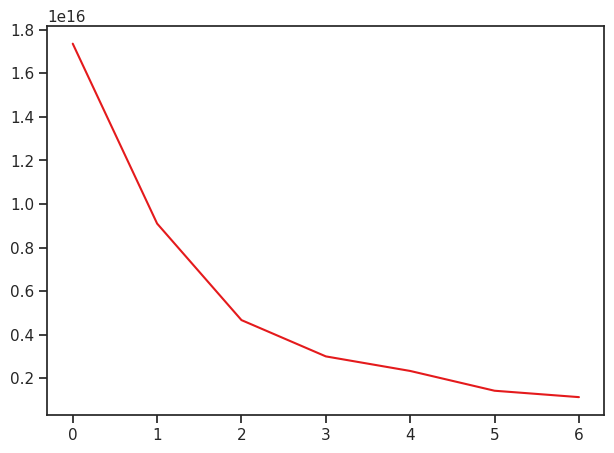

In [ ]:
# Elbow
#El método Elbow calcula la varianza total intra-cluster en función del número de clusters y escoge como óptimo aquel valor a partir del cual añadir más clusters apenas consigue mejoría.
ssd = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50)
    kmeans.fit(df)

    ssd.append(kmeans.inertia_)

# Gráfico
plt.plot(ssd)

In [ ]:
ssd

[1.7356266615087302e+16,
 9099433448555158.0,
 4668991929778386.0,
 3002987012262484.5,
 2334658337086740.5,
 1426956304220647.2,
 1133377424663575.0]

In [ ]:
# Modelo final k=2
kmeans1 = KMeans(n_clusters=2, max_iter=50)
kmeans1.fit(df)

KMeans(max_iter=50, n_clusters=2)

In [ ]:
# agregamos en la base df el agrupamiento con k medias

df['KM_2'] = kmeans1.labels_
# contamoss cuantos quedaron en cada grupo
print(pd.value_counts(df['KM_2']))
df.head()


KM_2
0    60
1    30
Name: count, dtype: int64


,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,porcentaje_inversion,porcentaje_costos,g1,g2,KM_2
0,112,6649054,4419184,1316702,2229870,59.05,66.46,2,3,0
1,445,9948595,9354345,268969,594250,45.26,94.03,2,3,0
2,870,30928216,27538110,172409,3390106,5.09,89.04,2,2,0
3,280,23329598,17800440,1646283,5529158,29.77,76.30,2,3,0
4,116,7275755,3876372,303618,3399383,8.93,53.28,2,2,0


In [ ]:
# Modelo final k=5
kmeans2 = KMeans(n_clusters=3, max_iter=50)
kmeans2.fit(df)

KMeans(max_iter=50, n_clusters=5)

In [ ]:
# agregamos en la base df el agrupamiento con k medias
# el cluster de 5 me da el mismo resultado que el de 2, es mas conveniente utlizar el de 2
df['KM_3'] = kmeans1.labels_
# contamoss cuantos quedaron en cada grupo
print(pd.value_counts(df['KM_3']))
df.head()


KM_3
0    60
1    30
Name: count, dtype: int64


,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,porcentaje_inversion,porcentaje_costos,g1,g2,KM_2,KM_5,KM_3
0,112,6649054,4419184,1316702,2229870,59.05,66.46,2,3,0,0,0
1,445,9948595,9354345,268969,594250,45.26,94.03,2,3,0,0,0
2,870,30928216,27538110,172409,3390106,5.09,89.04,2,2,0,0,0
3,280,23329598,17800440,1646283,5529158,29.77,76.30,2,3,0,0,0
4,116,7275755,3876372,303618,3399383,8.93,53.28,2,2,0,0,0


In [ ]:
# Cálculo del vector de medias por grupo
df.groupby(['KM_2'])[['cantidad_empleados', 'ventas_anuales_USD', 'sueldos_pagados_USD','inversión_anual_USD',	'ventas_netas',	'porcentaje_inversion',	'porcentaje_costos']].mean()

,cantidad_empleados,ventas_anuales_USD,sueldos_pagados_USD,inversión_anual_USD,ventas_netas,porcentaje_inversion,porcentaje_costos
KM_2,,,,,,,
0,337.483333,1.590465e+07,1.246817e+07,984408.733333,3.436476e+06,32.481333,73.090000
1,769.000000,4.919181e+07,4.546305e+07,891740.233333,3.728760e+06,29.047000,92.115333


<Axes: xlabel='KM_2', ylabel='cantidad_empleados'>

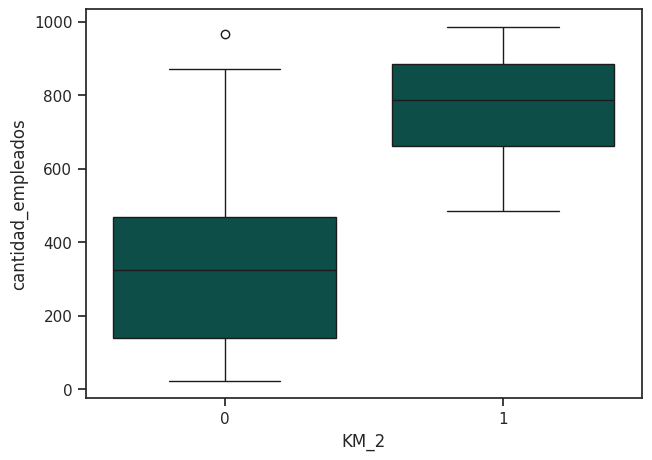

In [ ]:
# Box plot Cantidad de empleados

sns.boxplot(x='KM_2', y='cantidad_empleados',color="#025951",data=df)

<Axes: xlabel='KM_2', ylabel='ventas_anuales_USD'>

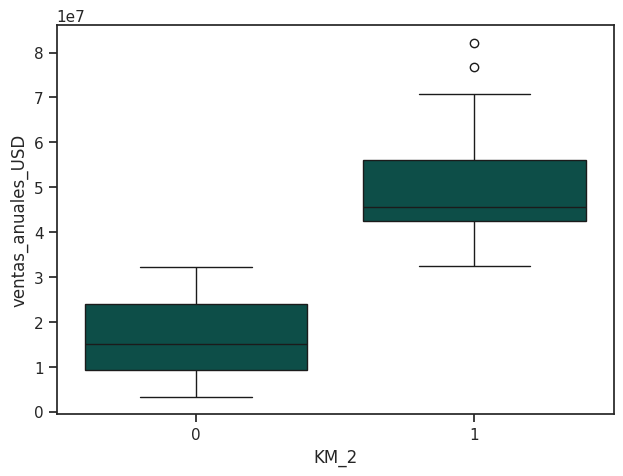

In [ ]:
# Box plot Ventas Anuales

sns.boxplot(x='KM_2', y='ventas_anuales_USD',color="#025951",data=df)

# **9. ANALISIS COMPARATIVO DE METODOS**

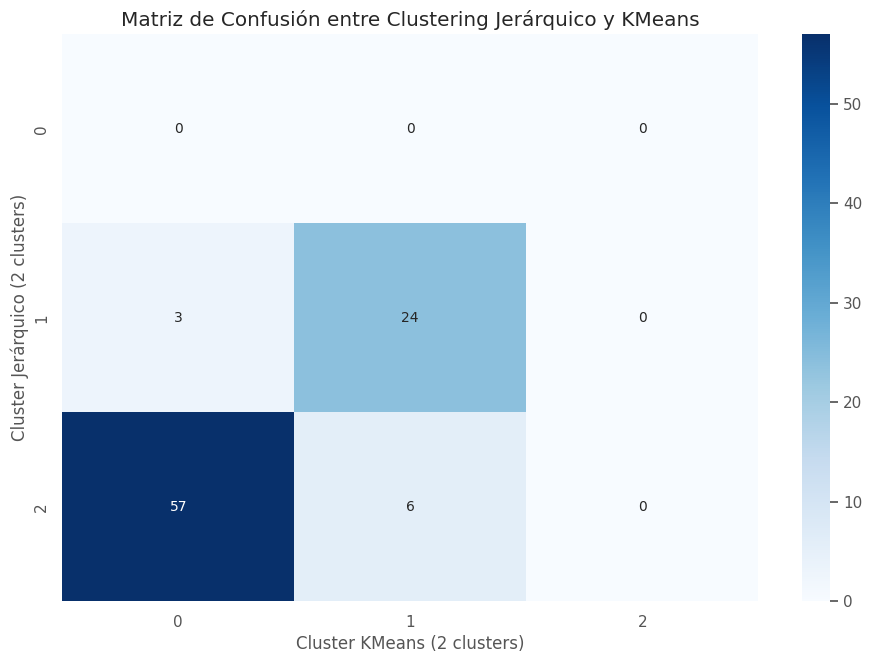

In [ ]:
# Matriz de Confusión
# Crear la matriz de confusión para clusters jerárquicos y KMeans (2 clusters)
conf_matrix = confusion_matrix(df['g1'], df['KM_2'])

# Visualizar la matriz de confusión
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Cluster KMeans (2 clusters)')
plt.ylabel('Cluster Jerárquico (2 clusters)')
plt.title('Matriz de Confusión entre Clustering Jerárquico y KMeans')
plt.show()

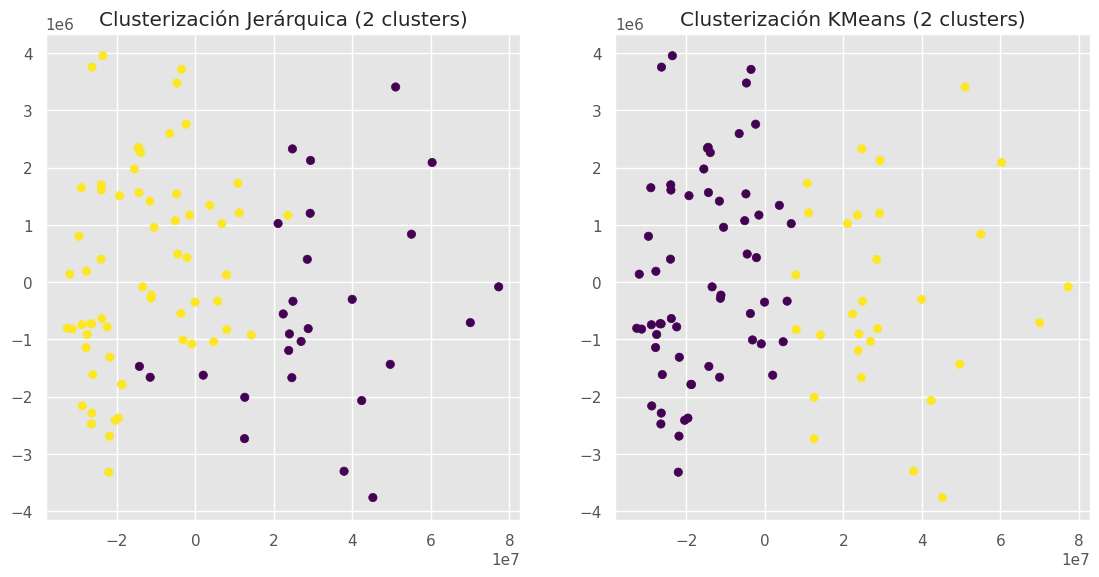

In [ ]:
# Reducir a 2D para visualización
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df)

# Visualización de los clusters
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=df['g1'], cmap='viridis')
plt.title('Clusterización Jerárquica (2 clusters)')

plt.subplot(1, 2, 2)
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=df['KM_2'], cmap='viridis')
plt.title('Clusterización KMeans (2 clusters)')

plt.show()